# iToF / Structured-Light Fusion Pipeline 

Calibration and depth fusion for a combined indirect Time-of-Flight (iToF) and Structured Light (SL) approach.
Based on:
- **Microsoft-Paper** – Godbaz et al. 2025 (Microsoft): dot calibration (4.1), 1-D dot trails, consistency error, active brightness trail (4.2)
- **Agresti** – Agresti & Zanuttigh, ECCV 2018: maximum likelihood depth fusion (eq. 16/17)


All heavy lifting lives in `dot_calibration.py`, `calibrate.py`
and `approaches.py`. So this notebook only orchestrates and visualizes.

In [2]:
from dot_calibration import DotCalibration
import approaches
import calibrate
import os
import numpy as np
from pathlib import Path
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import matplotlib.pyplot as plt

dotCal = DotCalibration()

# ── Camera / data selection / presets in calibrate.py
CAMERA = "SchmersalReal"          # "OnSemi" (Simulation) or "Schmersal" (Simulation) or "SchmersalReal" (First real measurement)
cfg     = calibrate.CAMERAS[CAMERA]
sl_cal  = cfg["sl_cal"]
tof_cal = cfg["tof_cal"]
K       = cfg["K"]          
CAL_BLOB_PARAMS = cfg["cal_blob"]
TOF_SAMPLE      = cfg.get("tof_sample")   # how to read ToF depth at a dot (see calibrate.CAMERAS)

K_inv = np.linalg.inv(K)
fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]

SUBPIXEL_MODE = "GPR"      # paper: LoG + GPR ("geometricCenter" as fallback)
TRACK_IN_TX_SPACE = False  # True: re-track in transmitter space (Godbaz 4.1)
BASELINE_OUTLIER_SIGMA = 3.0  # Godbaz: outlier-ray removal before the final Baseline fit
MIN_TRACK_POINTS = 3       # low-confidence invalidation: min distances per dot line
TRAIL_Z_MIN = 0.35          # trails run from here to infinity [m] (Godbaz: ~30 cm)

calibration_figures = []   # list of (name, fig)
print("Setup complete.")

Setup complete.


## Calibration Steps 1–2: Dot Detection, Subpixel Localisation & Tracking

LoG blob detection on each calibration SL image, followed by GPR
(Godbaz 4.1: LoG finds the area near the peak, a Gaussian-process model of the intensity
map is searched for the subpixel location). No fixed grid is assumed.

Stable IDs are then assigned by tracking each dot across the calibration distances with
a nearest-neighbor search; dots may enter/leave FOV between distances.

Calibration distances: [0.402, 0.439, 0.486, 0.545, 0.621, 0.72, 0.857, 1.059, 1.385, 2.0]
  Processing Pos0.exr …


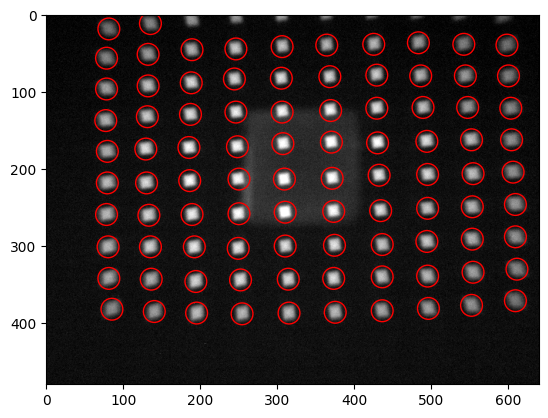

  Processing Pos1.exr …


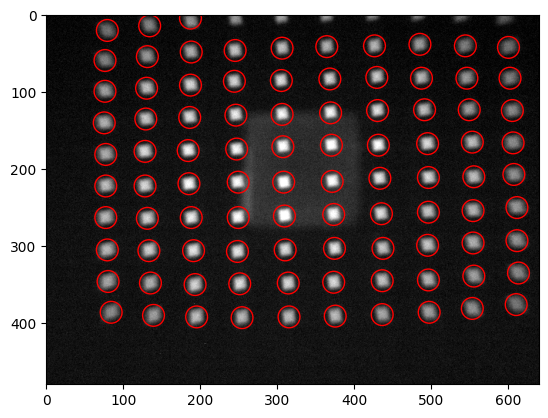

  Processing Pos2.exr …


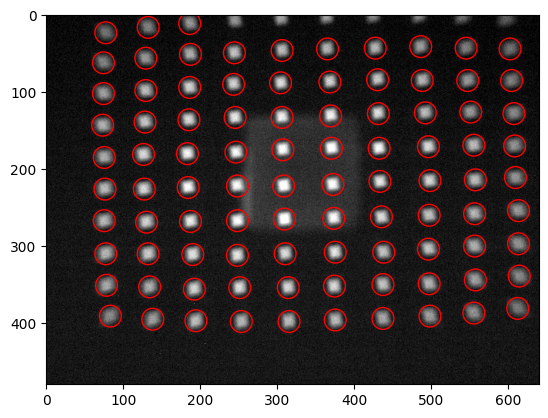

  Processing Pos3.exr …


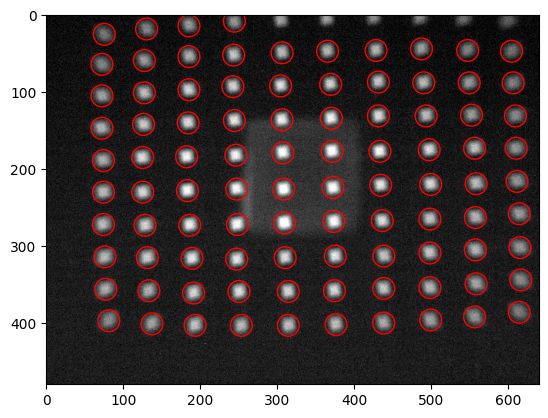

  Processing Pos4.exr …


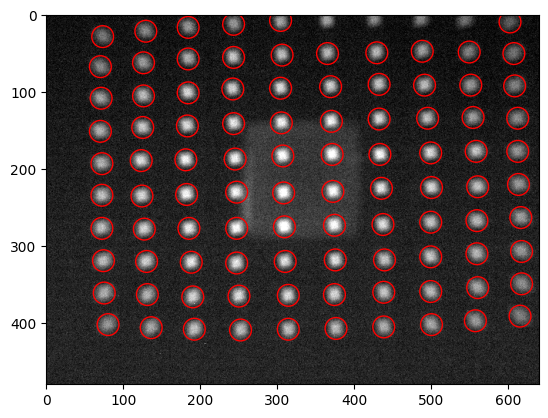

  Processing Pos5.exr …


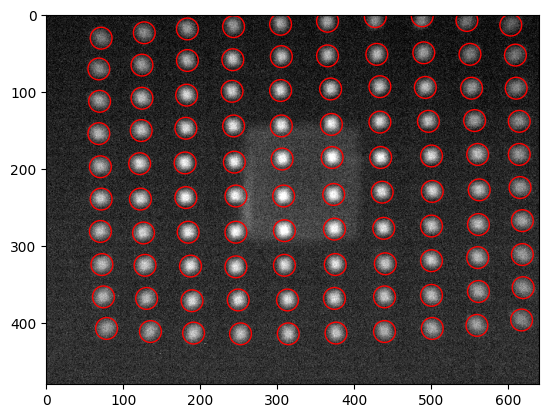

  Processing Pos6.exr …


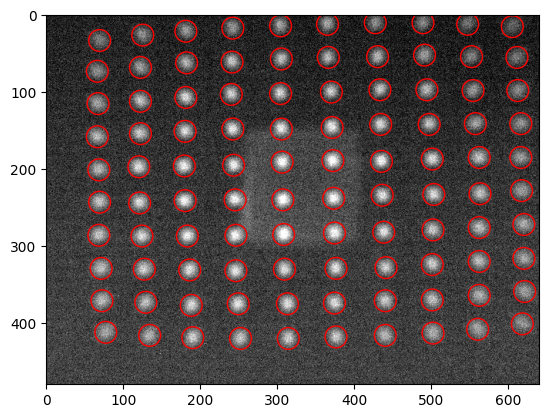

  Processing Pos7.exr …


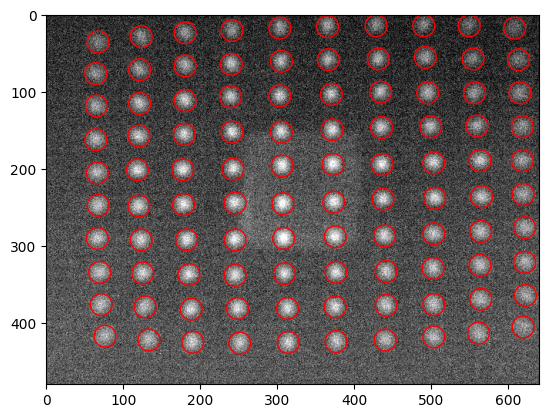

  Processing Pos8.exr …


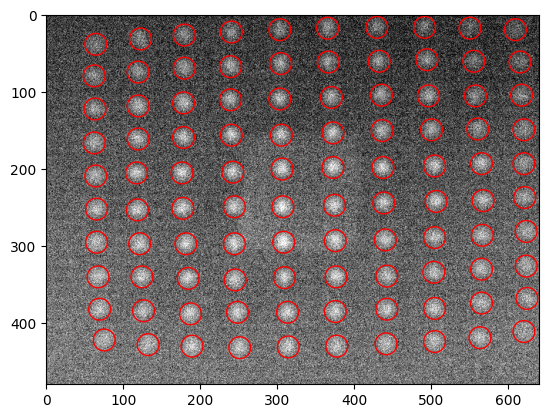

  Processing Pos9.exr …


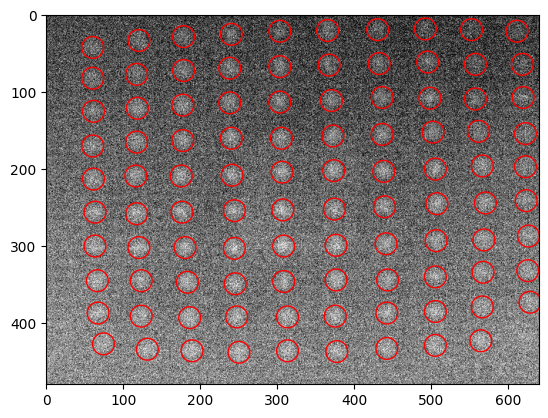


Dots per distance (raw, no grid enforced): [92, 93, 93, 94, 96, 100, 100, 100, 100, 99]
Tracked roster size: 100 dots
IDed dots per distance: [92, 93, 93, 94, 96, 100, 100, 100, 100, 99]


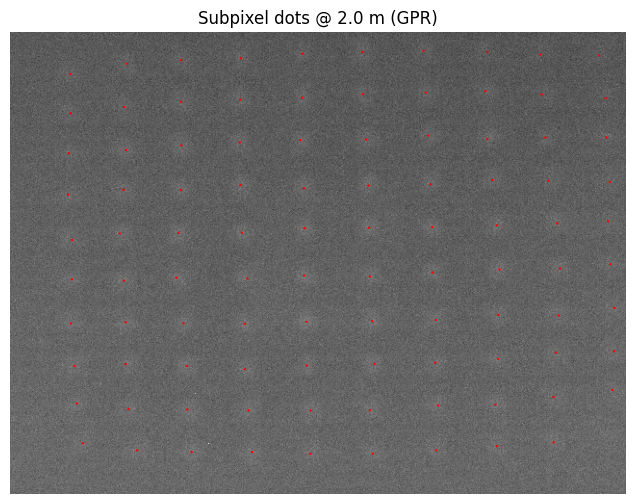

In [3]:
# Collect calibration PCD paths sorted by distance. Pattern and any excluded
# frames come from calibrate.CAMERAS (e.g. Pos9 @3.8 m unwraps wrongly).
EXCLUDE = set(cfg.get("exclude", ()))
pcd_files = sorted(
    (p for p in tof_cal.glob(cfg.get("pcd_glob", "ToF_*m.pcd"))
     if p.stem not in EXCLUDE),
    key=lambda p: calibrate.distance_for(cfg, dotCal, p) or 999.0
)

tof_paths = [str(p) for p in pcd_files]
cal_dists = [calibrate.distance_for(cfg, dotCal, p) for p in tof_paths]
print(f"Calibration distances: {cal_dists}")

# ── Steps 1+2: LoG blob detection + GPR subpixel refinement ─────────────
subpixel_list_unordered = []
for tof_p in tof_paths:
    sl_p = calibrate.find_sl_image(sl_cal, Path(tof_p).name)
    print(f"  Processing {Path(sl_p).name} …")
    blobs, image = dotCal.detect_blobs(str(sl_p), visualize=True, **CAL_BLOB_PARAMS)
    _, subpixels = dotCal.detect_subpixel_locations(blobs, image, mode=SUBPIXEL_MODE)
    subpixel_list_unordered.append(subpixels)

print(f"\nDots per distance (raw, no grid enforced): "
      f"{[len(s) for s in subpixel_list_unordered]}")

# ── Step 2b: cross-distance NN tracking -> stable IDs (Godbaz 4.1) ────────
subpixel_list = dotCal.track_dots_across_distances(
    subpixel_list_unordered, ref_idx=0, threshold_factor=0.5)

n_dots = max(int(d["id"]) for spx in subpixel_list for d in spx) + 1
print(f"Tracked roster size: {n_dots} dots")
print(f"IDed dots per distance: {[len(s) for s in subpixel_list]}")

# ── Visualize last calibration distance ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image, cmap="gray", alpha=0.8)
for d in subpixel_list[-1]:
    ax.add_patch(plt.Circle((d["x"], d["y"]), 0.5,
                            edgecolor="red", facecolor="none", linewidth=1))
ax.set_title(f"Subpixel dots @ {cal_dists[-1]} m ({SUBPIXEL_MODE})")
ax.axis("off")
calibration_figures.append(("step1_2_subpixel_dots", fig))
plt.show()

## Calibration Step 2c: X/Y Travel-Mode Detection

Detecting if the baseline travels in the x or y direction. (Simulatin: X, Real: Y)

With *TRACK_IN_TX_SPACE = True* the dots are re-tracked in the (approximately parallax
invariant) transmitter space using the derived baseline guess, as in the paper.

In [4]:
mode_info = dotCal.detect_travel_mode(subpixel_list, cal_dists, K)
mode = mode_info["mode"]
B_guess_vec = mode_info["B_guess_vec"]
print(f"Travel mode: {mode}")
print(f"du/dw = {mode_info['du_dw']:.2f} px·m,  dv/dw = {mode_info['dv_dw']:.2f} px·m")
print(f"Signed baseline estimate along {mode}: {mode_info['B_axis_est']*100:.3f} cm")
print(f"Signed baseline estimate along z: {mode_info['B_z_est']*100:.3f} cm "
      f"(from {mode_info['n_fit']} dots)")
print(f"B_guess_vec = {B_guess_vec}")

if TRACK_IN_TX_SPACE:
    coords_list = dotCal.tx_space_coords(
        subpixel_list_unordered, tof_paths, K=K, baseline_guess=B_guess_vec)
    subpixel_list = dotCal.track_dots_across_distances(
        subpixel_list_unordered, ref_idx=0, threshold_factor=0.5,
        coords_list=coords_list, travel_mode=mode)
    n_dots = max(int(d["id"]) for spx in subpixel_list for d in spx) + 1
    print(f"Re-tracked in transmitter space: roster {n_dots} dots")

Travel mode: y
du/dw = 0.14 px·m,  dv/dw = -18.92 px·m
Signed baseline estimate along y: -3.760 cm
Signed baseline estimate along z: 3.139 cm (from 100 dots)
B_guess_vec = [ 0.00083253 -0.03760109  0.0313942 ]


## Calibration Step 3: 3-D Back-Projection

For each detected dot at pixel (u, v), the iToF measurement is sampled
bilinearly to obtain the 3-D point U_ij in camera coordinates; U_tx = U − B_guess.

U shape:    (100, 10, 3)     (n_dots × n_dist × xyz)
U_tx shape: (100, 10, 3)  (shifted by B_guess = [ 0.00083253 -0.03760109  0.0313942 ])


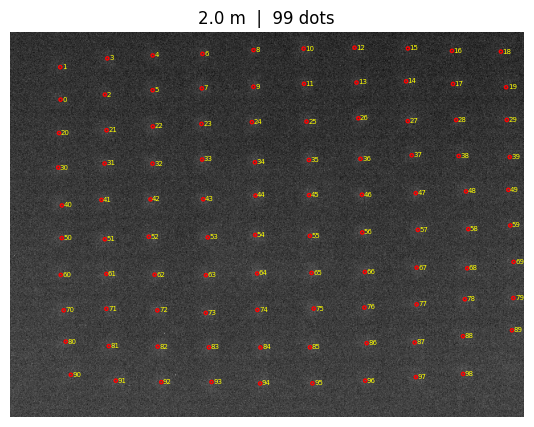

In [5]:
U, U_tx = dotCal.backproject_calibration_dots(
    subpixel_list, tof_paths, K=K,
    pcd_depth_mode="radial",
    baseline_guess=B_guess_vec,
    tof_sample=TOF_SAMPLE,       # "annulus" on the real rig: the projector is on
)                                # during the ToF capture and saturates the dots
print(f"U shape:    {U.shape}     (n_dots × n_dist × xyz)")
print(f"U_tx shape: {U_tx.shape}  (shifted by B_guess = {B_guess_vec})")

# ── Plot: dot IDs at the farthest distance ─────────────────────────────
sl_far = calibrate.find_sl_image(sl_cal, Path(tof_paths[-1]).name)
img = dotCal.read_image(str(sl_far))
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(img, cmap="gray")
for dot in subpixel_list[-1]:
    ax.add_patch(plt.Circle((dot["x"], dot["y"]), 2,
                            edgecolor="red", facecolor="none", linewidth=1))
    ax.text(dot["x"] + 2, dot["y"] + 2, str(dot["id"]),
            fontsize=5, color="yellow")
ax.set_title(f"{cal_dists[-1]} m  |  {len(subpixel_list[-1])} dots")
ax.axis("off")
calibration_figures.append((f"step3_dotids_{cal_dists[-1]}m", fig))
plt.show()

## Calibration Step 4: Baseline Estimation (full 3-D)

Fit a 3D line through each dots calibration distance (in U_tx space), then find
the least-squares intersection of all lines. The full 3D intersection in the origin corrects the
initial guess: `B = B_guess + intersection`.

Multi-stage outlier removal (Godbaz 4.1): dots observed at fewer than `MIN_TRACK_POINTS`
distances contribute no line. With `BASELINE_OUTLIER_SIGMA` set, outlier rays are removed
before the final fit ("After removing outlier rays, the baseline AB is found by an
additional least squares optimization").

Fitted 91 dot lines (after outlier removal)
LS intersection (U_tx):  [ 0.00011599 -0.00053294  0.00135558]
B = [ 0.00094852 -0.03813404  0.03274978]   (AB along y: -3.8134 cm)


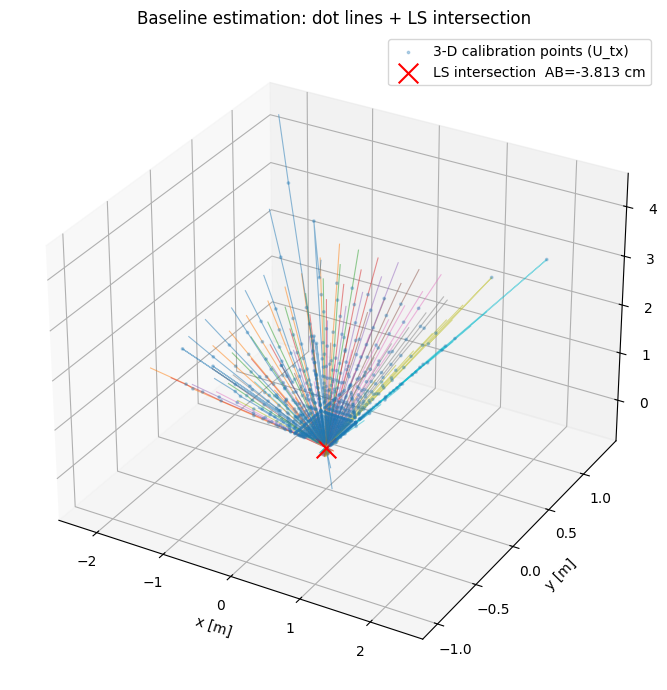

In [6]:
intersection, n_lines = dotCal.estimate_baseline(
    U_tx, outlier_sigma=BASELINE_OUTLIER_SIGMA, min_points=MIN_TRACK_POINTS)

B  = B_guess_vec + intersection
axis = 0 if mode == "x" else 1
AB = float(B[axis])

print(f"Fitted {n_lines} dot lines (after outlier removal)")
print(f"LS intersection (U_tx):  {intersection}")
print(f"B = {B}   (AB along {mode}: {AB*100:.4f} cm)")

# ── 3-D plot: points + lines + intersection ─────────────────────────────
all_pts = U_tx.reshape(-1, 3)
all_pts = all_pts[np.all(np.isfinite(all_pts), axis=1)]

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(all_pts[:, 0], all_pts[:, 1], all_pts[:, 2],
           s=3, alpha=0.3, label="3-D calibration points (U_tx)")
cmap = plt.cm.tab10
for i in range(U_tx.shape[0]):
    pts = U_tx[i, :, :]
    valid = np.all(np.isfinite(pts), axis=1)
    if valid.sum() < 2:
        continue
    pts_v = pts[valid]
    direction = pts_v[-1] - pts_v[0]
    extended = np.vstack([(pts_v[0] - 0.3 * direction)[None, :], pts_v,
                          (pts_v[-1] + 0.3 * direction)[None, :]])
    ax.plot(extended[:, 0], extended[:, 1], extended[:, 2],
            color=cmap(i % 10), alpha=0.5, linewidth=0.8)
ax.scatter(*intersection, s=200, marker="x", color="red",
           label=f"LS intersection  AB={AB*100:.3f} cm")
ax.set_title("Baseline estimation: dot lines + LS intersection")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
plt.tight_layout()
calibration_figures.append(("step4_baseline_3d", fig))
plt.show()

## Calibration Step 5: Unit Vector Estimation

For each dot i, fit a unit direction vector V[i] by minimising the angle between
the fitted ray and each calibration point Q_ij = U_ij − B (dots entering/leaving the FOV still get a V).

Unit vectors estimated: 100 / 100


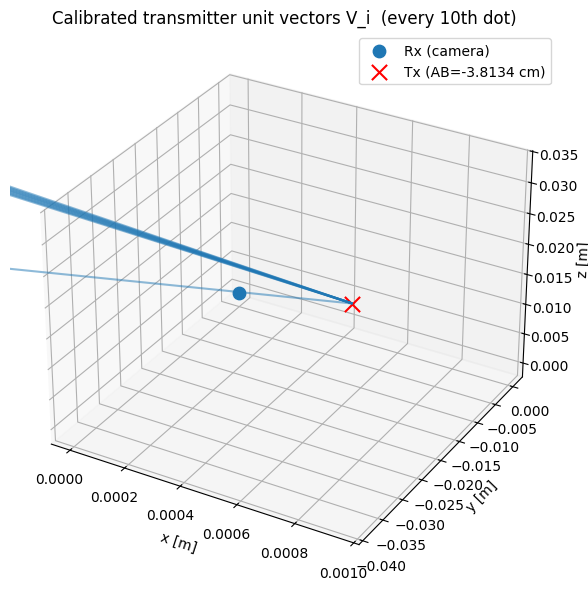

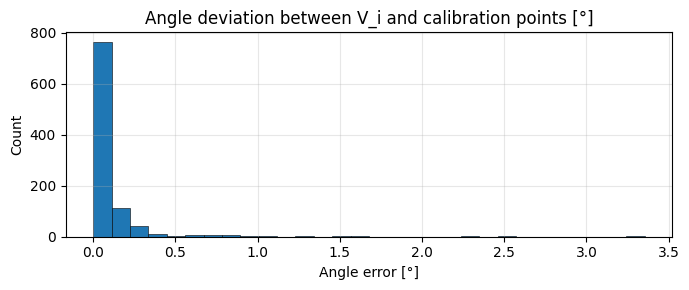

Median angle error: 0.05759°
Max angle error:    3.35419°


In [7]:
V = dotCal.estimate_unit_vectors(U, B)
V_valid = V[np.all(np.isfinite(V), axis=1)]
print(f"Unit vectors estimated: {len(V_valid)} / {V.shape[0]}")

angle_errs = []
for i in range(V.shape[0]):
    if not np.all(np.isfinite(V[i])):
        continue
    pts   = U[i, :, :]
    valid = np.all(np.isfinite(pts), axis=1)
    Q     = pts[valid] - B[None, :]
    Qn    = Q / (np.linalg.norm(Q, axis=1, keepdims=True) + 1e-12)
    angle_errs.extend(np.degrees(np.arccos(np.clip(Qn @ V[i], -1, 1))).tolist())

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter([0], [0], [0], s=80, marker="o", label="Rx (camera)")
ax.scatter([B[0]], [B[1]], [B[2]], s=120, marker="x", color="red",
           label=f"Tx (AB={AB*100:.4f} cm)")
for i in range(0, V.shape[0], 10):
    if not np.all(np.isfinite(V[i])):
        continue
    ax.quiver(B[0], B[1], B[2], V[i, 0], V[i, 1], V[i, 2],
              length=0.4, normalize=True, alpha=0.5)
ax.set_title("Calibrated transmitter unit vectors V_i  (every 10th dot)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
plt.tight_layout()
calibration_figures.append(("step5_unit_vectors", fig))
plt.show()

plt.figure(figsize=(7, 3))
plt.hist(np.array(angle_errs), bins=30, edgecolor="k", linewidth=0.4)
plt.title("Angle deviation between V_i and calibration points [°]")
plt.xlabel("Angle error [°]"); plt.ylabel("Count")
plt.grid(alpha=0.3); plt.tight_layout()
calibration_figures.append(("step5_angle_error_hist", plt.gcf()))
plt.show()

print(f"Median angle error: {np.median(angle_errs):.5f}°")
print(f"Max angle error:    {np.max(angle_errs):.5f}°")

## Calibration Step 6: 1-D Dot Trails + Noise Estimates

The dot trails are precomputed as 1D Vector (Godbaz 4.2).

Calibration also measures the noise levels used by Approach 2:
- **σ_u** [px]: residual of all detections to their trail line
- **σ_ToF(z)**: robust std of the dots ToF depths per distance

Trails: 100 dots, 49 samples on average (z: 0.4 m -> ∞)
sigma_u (2-D cal residual) = 0.2449 px
sigma_u_ab (1-D runtime AB) = 0.3465 px
sigma_ToF(z):
  z = 0.402 m  ->  σ = 5.75 mm
  z = 0.437 m  ->  σ = 5.49 mm
  z = 0.482 m  ->  σ = 4.95 mm
  z = 0.539 m  ->  σ = 4.75 mm
  z = 0.612 m  ->  σ = 5.12 mm
  z = 0.709 m  ->  σ = 7.43 mm
  z = 0.851 m  ->  σ = 6.92 mm
  z = 1.052 m  ->  σ = 9.49 mm
  z = 1.378 m  ->  σ = 15.41 mm
  z = 1.993 m  ->  σ = 19.15 mm


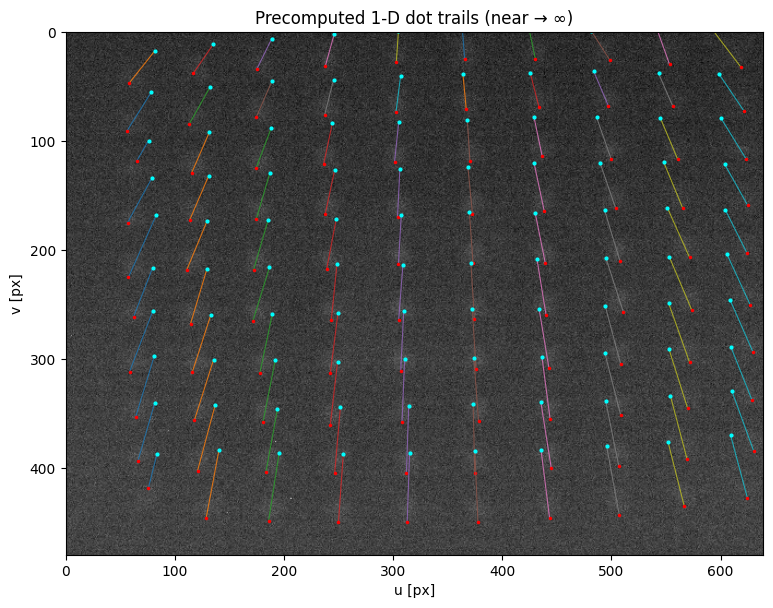

In [8]:
image_shape = image.shape[:2]
TRAIL_Z_MIN = 0.4  # trails run from here to infinity [m] (Godbaz: ~30 cm)
trails = dotCal.fit_trails_from_detections(
    subpixel_list, U, z_min=TRAIL_Z_MIN, step_px=1.0,
    image_shape=image_shape, V=V, B=B, K=K)
n_trails = sum(1 for t in trails if t is not None)
lens = [len(t["u"]) for t in trails if t is not None]
print(f"Trails: {n_trails} dots, {int(np.mean(lens))} samples on average "
      f"(z: {TRAIL_Z_MIN} m -> ∞)")

sigma_u = dotCal.estimate_sigma_u_trails(subpixel_list, trails)
sigma_tof_table = dotCal.estimate_sigma_tof(U, expected_z=cal_dists)
sl_paths = [calibrate.find_sl_image(sl_cal, Path(p).name) for p in tof_paths]
sigma_u_ab = calibrate.estimate_sigma_u_ab(dotCal, subpixel_list, trails, sl_paths, TRAIL_Z_MIN)
print(f"sigma_u (2-D cal residual) = {sigma_u:.4f} px")
print(f"sigma_u_ab (1-D runtime AB) = {sigma_u_ab:.4f} px")
print("sigma_ToF(z):")
for z, s in sigma_tof_table:
    print(f"  z = {z:.3f} m  ->  σ = {s*1e3:.2f} mm")

# ── Trail visualization 
fig = dotCal.plot_dot_trails(trails, image_shape=image_shape, background=image)
calibration_figures.append(("step6_dot_trails", fig))
plt.show()

## Save Calibration

Writes the extended `calibration.json` (incl. mode, full 3-D B, precomputed trails,
σ_u, σ_ToF table) to `Calibrations/<CAL_NAME>/`. Set `CAL_NAME`/`SAVE_PLOTS` below.

In [8]:
import json as _json
from datetime import datetime as _dt

CAL_NAME   = f"{CAMERA}_paperlike"   # -> Calibrations/<CAL_NAME>/calibration.json
SAVE_PLOTS = True

cal_dir = Path.cwd().parent / "Calibrations" / CAL_NAME
cal_dir.mkdir(parents=True, exist_ok=True)

cal_data = calibrate.sanitize({
    "metadata": {
        "created": _dt.now().isoformat(),
        "camera": CAMERA,
        "sl_cal_path": str(sl_cal),
        "tof_cal_path": str(tof_cal),
        "pipeline": "codePaperlike",
        "mode": mode,
        "baseline_guess": B_guess_vec.tolist(),
        "subpixel_mode": SUBPIXEL_MODE,
        "pcd_depth_mode": "radial",
        "tof_sample": TOF_SAMPLE,
        "pcd_unit_scale": 0.001,
        "track_in_tx_space": TRACK_IN_TX_SPACE,
        "baseline_outlier_sigma": BASELINE_OUTLIER_SIGMA,
        "baseline_min_points": MIN_TRACK_POINTS,
        "trail_z_min": TRAIL_Z_MIN,
        "fx": float(fx), "fy": float(fy),
        "cx": float(cx), "cy": float(cy),
    },
    "mode": mode,
    "K": K.tolist(),
    "K_inv": K_inv.tolist(),
    "V": V.tolist(),
    "B": B.tolist(),
    "AB": AB,
    "BASELINE_GUESS": B_guess_vec.tolist(),
    "cal_dists": [float(d) for d in cal_dists],
    "subpixel_list": subpixel_list,
    "U": U.tolist(),
    "trails": [None if t is None else
               {"u": t["u"].tolist(), "v": t["v"].tolist(), "w": t["w"].tolist()}
               for t in trails],
    "sigma_u": float(sigma_u),
    "sigma_u_ab": float(sigma_u_ab),
    "sigma_tof_table": sigma_tof_table.tolist(),
})

cal_file = cal_dir / "calibration.json"
with open(cal_file, "w") as f:
    _json.dump(cal_data, f)
print(f"Calibration saved to {cal_file}")

if SAVE_PLOTS:
    for name, fig in calibration_figures:
        fig.savefig(str(cal_dir / f"{name}.png"), dpi=150, bbox_inches="tight")
    print(f"Saved {len(calibration_figures)} plot(s) to {cal_dir}")

Calibration saved to /home/julian/Documents/Github/iToF-SL-Combination/Calibrations/SchmersalReal_paperlike/calibration.json


Saved 6 plot(s) to /home/julian/Documents/Github/iToF-SL-Combination/Calibrations/SchmersalReal_paperlike


## Noise / Repeatability Measurement

Everything above is the **unchanged** calibration pipeline of `iToF_SL_fusion_pipeline.ipynb`.

From here on the notebook no longer evaluates a single test frame. It sweeps the repeatability
dataset

```
/home/julian/Documents/Calibrations/RauschmessungiToF10x10450375050step/ToFPCD/<d>m/Nr<0..99>.pcd
```

— 67 distances (0.45 m … 3.75 m in 5 cm steps) × 100 repeated captures of the same static flat
wall = **6700 frames**. Every frame is pushed through **all three approaches** (20 100 runs), so
for each of the 100 dots at each distance we get a distribution of 100 depth measurements.

From that we read off

* the **per-dot** noise — a 10×10 grid of error histograms laid out like the dot pattern
  (top-left = grid position (0,0), bottom-right = (9,9)), for freely selectable distances, and
* the **overall** noise per distance — σ vs. distance, one curve per approach.

The active-brightness images the approaches need are generated once from the same PCDs with
`pcdToExr.py` (the `grayValue` field → single-channel EXR).

`DISTANCE_RANGE` in the configuration cell restricts every table and figure below to a
sub-range — set it to `[0.40, 2.00]` to work on the near half first. Changing it is free: the
sweep is checkpointed per distance, so a narrower (or wider) range only re-assembles cached
results instead of re-running any frame.

> **Caveat, Approach 2 only.** `cal["sigma_tof_table"]` spans 0.402 – 2.0 m and
> `approaches.sigma_models` interpolates it with `np.interp`, which *clamps* outside that range.
> Beyond 2 m Approach 2 therefore weights iToF with the σ measured at 2.0 m. That shifts the
> fusion weights; it does not affect the measured σ of Approaches 1 and 3.

In [9]:
# ── Noise-sweep configuration ────────────────────────────────────────────────
# Deliberately free of calibration dependencies, so cells 21+ can re-plot from the
# cached .npz in a fresh kernel with only this cell and the import cell run.
import contextlib
import io
import multiprocessing as mp
import re
import subprocess
import sys
import time
import warnings

NOISE_PCD_ROOT = Path("/home/julian/Documents/Calibrations/"
                      "RauschmessungiToF10x10450375050step/ToFPCD")
NOISE_EXR_ROOT = Path("/home/julian/Documents/Calibrations/RauschmessungEXR")
CACHE_DIR      = Path.cwd().parent / "Results" / "noise_estimation"
RESULT_NPZ     = CACHE_DIR / "noise_summary.npz"

N_WORKERS       = 5      # 0 → run serially (easier to debug)
FORCE_RERUN     = False  # True → redo the EXR conversion and the sweep, ignoring caches
MIN_VALID       = 10     # repeats a dot needs before its σ is reported
# Which distances to analyse. Narrowing this re-runs NOTHING — the sweep is
# checkpointed per distance, so the range only selects which cached blocks are
# assembled and therefore which distances every table and figure below covers.
DISTANCE_RANGE  = [0.40, 2.00]   # [lower, upper] ground truth [m], inclusive;
                                 # None → the whole 0.45 … 3.75 m sweep
LIMIT_DISTANCES = None   # e.g. 2 → smoke test on the first two distances only

CACHE_DIR.mkdir(parents=True, exist_ok=True)

SERIES = [
    "Approach 1 — consistency error (ToF @ min-ε)",
    "Approach 2 — Gaussian ML fusion",
    "Approach 3 — active brightness (triangulated)",
    "Approach 2 input: iToF only",
    "Approach 2 input: SL only",
]
N_SERIES = len(SERIES)

# Okabe–Ito, assigned in fixed order — never cycled, never reassigned when a
# series is hidden, so a colour always means the same approach.
SERIES_COLOR = ["#0072B2", "#D55E00", "#009E73", "#56B4E9", "#CC79A7"]
SERIES_STYLE = ["-", "-", "-", "--", "--"]
SERIES_LW    = [2.0, 2.0, 2.0, 1.2, 1.2]

_rng = ("0.45 … 3.75 m (all)" if DISTANCE_RANGE is None
        else f"{DISTANCE_RANGE[0]:.2f} … {DISTANCE_RANGE[1]:.2f} m")
print(f"{N_SERIES} result series  |  distance range: {_rng}")
print(f"PCD root : {NOISE_PCD_ROOT}")
print(f"EXR root : {NOISE_EXR_ROOT}")
print(f"cache    : {CACHE_DIR}")

5 result series  |  distance range: 0.40 … 2.00 m
PCD root : /home/julian/Documents/Calibrations/RauschmessungiToF10x10450375050step/ToFPCD
EXR root : /home/julian/Documents/Calibrations/RauschmessungEXR
cache    : /home/julian/Documents/Github/iToF-SL-Combination/Results/noise_estimation


### Step A — Active-brightness EXRs

The approaches read the SL/active-brightness image through `DotCalibration.read_image`, so the
`grayValue` field of every noise PCD is exported once to a single-channel EXR with the repo's
`pcdToExr.py` (unmodified). Idempotent: the cell skips the conversion once the EXR count matches
the PCD count.

In [10]:
# ── Step A: convert every noise PCD to a single-channel AB EXR ───────────────
# Uses the repo's pcdToExr.py unchanged: it reads the PCD `grayValue` field and
# writes it to the channel `DotCalibration.SL_CHANNEL`, mirroring the folder
# structure (…/ToFPCD/0.45m/Nr0.pcd → …/RauschmessungEXR/0.45m/Nr0.exr).
n_pcd = sum(1 for _ in NOISE_PCD_ROOT.rglob("*.pcd"))
n_exr = sum(1 for _ in NOISE_EXR_ROOT.rglob("*.exr")) if NOISE_EXR_ROOT.exists() else 0
print(f"{n_pcd} PCDs  |  {n_exr} EXRs already present")

if FORCE_RERUN or n_exr != n_pcd:
    script = Path.cwd().parent / "pcdToExr.py"
    cmd = [sys.executable, str(script), str(NOISE_PCD_ROOT), str(NOISE_EXR_ROOT)]
    print("running:", " ".join(cmd), "\n(this reads ~93 GB and writes ~8 GB — a few minutes)")
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    for line in proc.stdout.strip().splitlines()[-3:]:
        print(" ", line)
    if proc.returncode != 0:
        print("STDERR:", proc.stderr[-2000:])
    print(f"conversion took {time.time() - t0:.0f} s")
    n_exr = sum(1 for _ in NOISE_EXR_ROOT.rglob("*.exr"))
    print(f"{n_exr}/{n_pcd} EXRs now present")
else:
    print("EXRs complete — skipping conversion (set FORCE_RERUN = True to redo)")

# Spot check: does the EXR read back through the same loader the approaches use?
probe_exr = NOISE_EXR_ROOT / "0.45m" / "Nr0.exr"
probe_pcd = NOISE_PCD_ROOT / "0.45m" / "Nr0.pcd"
if probe_exr.exists():
    img = dotCal.read_image(str(probe_exr))
    ref = dotCal.load_tof_pcd(str(probe_pcd), unit_scale=0.001,
                              depth_mode="axial")["intensity_map"]
    print(f"spot check {probe_exr.relative_to(NOISE_EXR_ROOT)}: shape={img.shape} "
          f"dtype={img.dtype} range={img.min():.1f}..{img.max():.1f}  "
          f"max|EXR-grayValue| = {np.nanmax(np.abs(img - ref)):.3g}")

6700 PCDs  |  6700 EXRs already present
EXRs complete — skipping conversion (set FORCE_RERUN = True to redo)
spot check 0.45m/Nr0.exr: shape=(480, 640) dtype=float32 range=159.1..557.7  max|EXR-grayValue| = 0


### Step B — 10×10 display layout

The requested figure layout is *grid position*, not dot ID. The mapping is derived from the
calibration detections, so `grid_ids[0, 0]` is the top-left dot and `grid_ids[9, 9]` the
bottom-right one.

In [11]:
# ── Step B: 10×10 display layout ─────────────────────────────────────────────
# Dot IDs come from the NN tracker and are NOT grid positions: ids 20…99 happen to
# match rows 2…9, but ids 0…19 interleave the top two rows (dot 0 sits at y≈73,
# dot 1 at y≈33). Derive the layout from the calibration detections at a distance
# where all dots were found: sort by y → ten rows → sort each row by x.
N_DOTS = len(trails)
assert N_DOTS == 100, f"expected a 10×10 pattern, got {N_DOTS} trails"

_full = next(s for s in subpixel_list if len(s) == N_DOTS)
_ids = np.array([d["id"] for d in _full])
_x   = np.array([d["x"] for d in _full], float)
_y   = np.array([d["y"] for d in _full], float)

_rows = np.argsort(_y).reshape(10, 10)                              # ten y-bands
grid_ids = np.array([_ids[r[np.argsort(_x[r])]] for r in _rows])    # (10, 10)

assert sorted(grid_ids.ravel().tolist()) == list(range(N_DOTS)), "layout is not a permutation"
print("Display grid (row 0 = top of the image, column 0 = left):")
for r in range(10):
    ys = _y[[int(np.where(_ids == g)[0][0]) for g in grid_ids[r]]]
    print("  " + " ".join(f"{g:3d}" for g in grid_ids[r])
          + f"   | y = {ys.min():3.0f}…{ys.max():3.0f} px")

Display grid (row 0 = top of the image, column 0 = left):
    1   3   4   6   8  10  12  15  16  18   | y =   8… 30 px
    0   2   5   7   9  11  13  14  17  19   | y =  49… 71 px
   20  21  22  23  24  25  26  27  28  29   | y =  93…112 px
   30  31  32  33  34  35  36  37  38  39   | y = 137…155 px
   40  41  42  43  44  45  46  47  48  49   | y = 181…197 px
   50  51  52  53  54  55  56  57  58  59   | y = 224…239 px
   60  61  62  63  64  65  66  67  68  69   | y = 267…283 px
   70  71  72  73  74  75  76  77  78  79   | y = 311…328 px
   80  81  82  83  84  85  86  87  88  89   | y = 354…371 px
   90  91  92  93  94  95  96  97  98  99   | y = 396…414 px


### Step C — The sweep

6700 frames × 3 approaches. One `common_setup` per frame feeds all three runners, all plotting is
off, and every runner's stdout is swallowed. Work is spread over `N_WORKERS` forked processes and
checkpointed per distance in `Results/noise_estimation/`, so the run resumes after an interrupt.

Alongside the three approach outputs, Approach 2's two *inputs* (the iToF depth and the
triangulated SL depth at the same dot) are recorded — they come for free from
`ab_trail_candidates` and show what the fusion is actually fusing.

Expect roughly 5–8 minutes on 5 cores; ~20 minutes serially.

In [12]:
# ── Step C: the sweep — 6700 frames × 3 approaches ───────────────────────────
# Per frame: one common_setup (PCD + EXR load) feeds all three approaches.
# Results are checkpointed per distance, so an interrupted run resumes.

# Calibration dict handed to approaches.py — identical to the fusion notebook's.
cal = {
    "K": K, "K_inv": K_inv, "V": V, "B": B,
    "AB": AB, "mode": mode,
    "U": U, "cal_dists": [float(d) for d in cal_dists],
    "subpixel_list": subpixel_list,
    "trails": trails,
    "sigma_u": float(sigma_u), "sigma_u_ab": float(sigma_u_ab),
    "sigma_tof_table": sigma_tof_table,
    "metadata": {"pcd_unit_scale": 0.001, "trail_z_min": TRAIL_Z_MIN, "mode": mode},
}

def _dist_of(folder):
    """Ground truth [m] from a folder name like '0.50m'.

    `parse_distance_from_name` runs `os.path.splitext` first, which would eat
    '.50m' as the extension — appending a dummy suffix keeps the stem intact.
    """
    d = dotCal.parse_distance_from_name(folder.name + ".pcd")
    if d is None:
        raise ValueError(f"cannot parse a distance from folder {folder.name!r}")
    return float(d)


dist_dirs = sorted((p for p in NOISE_PCD_ROOT.iterdir() if p.is_dir()), key=_dist_of)
n_all = len(dist_dirs)
if DISTANCE_RANGE is not None:
    _lo, _hi = DISTANCE_RANGE
    dist_dirs = [p for p in dist_dirs if _lo - 1e-9 <= _dist_of(p) <= _hi + 1e-9]
    if not dist_dirs:
        raise ValueError(f"DISTANCE_RANGE {DISTANCE_RANGE} selects none of the "
                         f"{n_all} measured distances")
if LIMIT_DISTANCES:
    dist_dirs = dist_dirs[:LIMIT_DISTANCES]
dists = np.array([_dist_of(p) for p in dist_dirs], float)
print(f"{len(dist_dirs)} of {n_all} distances: {dists.min():.2f} … {dists.max():.2f} m "
      f"({len(dist_dirs) * 100} frames × 3 approaches)")

_W = {}


def _init_worker(cal_dict):
    """One DotCalibration + calibration dict per worker process."""
    _W["dotCal"] = DotCalibration()
    _W["cal"] = cal_dict


def _run_frame(task):
    """All three approaches on one frame. Returns (repeat_index, (N_SERIES, N_DOTS))."""
    dname, k = task
    out = np.full((N_SERIES, N_DOTS), np.nan, np.float32)
    sl_p = str(NOISE_EXR_ROOT / dname / f"Nr{k}.exr")
    tof_p = str(NOISE_PCD_ROOT / dname / f"Nr{k}.pcd")
    d, c = _W["dotCal"], _W["cal"]
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            setup = approaches.common_setup(d, c, sl_p, tof_p)
            r1 = approaches.run_approach_1(d, c, setup, make_plots=False)
            r2 = approaches.run_approach_2(d, c, setup, make_plots=False)
            r3 = approaches.run_approach_3(d, c, setup, make_plots=False)
    except Exception as exc:                                    # noqa: BLE001
        print(f"  [warn] {dname}/Nr{k}: {type(exc).__name__}: {exc}")
        return k, out
    # index by r["i"] (the dot id) — the runners skip uncalibrated trails
    for r in r1["results"]:
        out[0, r["i"]] = r["Z_out"]
    for r in r2["results"]:
        out[1, r["i"]] = r["z_fus"]
        if np.isfinite(r["z_fus"]):          # same gate the fusion applied
            out[3, r["i"]] = r["z_tof"]
            out[4, r["i"]] = r["z_sl"]
    for r in r3["results"]:
        out[2, r["i"]] = r["Z_out"]
    return k, out


def run_sweep():
    ctx = mp.get_context("fork")     # children inherit the notebook globals
    pool = ctx.Pool(N_WORKERS, initializer=_init_worker, initargs=(cal,)) if N_WORKERS else None
    if pool is None:
        _init_worker(cal)
    t_start, n_done = time.time(), 0
    todo = [f for f in dist_dirs
            if FORCE_RERUN or not (CACHE_DIR / f"d_{f.name}.npz").exists()]
    print(f"{len(dist_dirs) - len(todo)} distances cached, {len(todo)} to run")
    try:
        for folder in todo:
            ks = sorted(int(re.search(r"Nr(\d+)", p.stem).group(1))
                        for p in folder.glob("*.pcd"))
            pos = {k: j for j, k in enumerate(ks)}
            block = np.full((N_SERIES, len(ks), N_DOTS), np.nan, np.float32)
            tasks = [(folder.name, k) for k in ks]
            it = (pool.imap_unordered(_run_frame, tasks, chunksize=4) if pool
                  else map(_run_frame, tasks))
            for k, arr in it:
                block[:, pos[k], :] = arr
            np.savez_compressed(CACHE_DIR / f"d_{folder.name}.npz", block=block,
                                repeats=np.array(ks, np.int32),
                                dist=_dist_of(folder))
            n_done += 1
            el = time.time() - t_start
            eta = el / n_done * (len(todo) - n_done)
            frac = np.isfinite(block[:3]).mean(axis=(1, 2))
            print(f"[{n_done}/{len(todo)}] {folder.name}: {len(ks)} frames, "
                  f"valid A1/A2/A3 = {frac[0]:.0%}/{frac[1]:.0%}/{frac[2]:.0%}  "
                  f"| {el/60:.1f} min elapsed, ~{eta/60:.1f} min left")
    finally:
        if pool is not None:
            pool.close()
            pool.join()


run_sweep()

# ── assemble the selected blocks into Z[series, distance, repeat, dot] ───────
# Only the distances inside DISTANCE_RANGE go into RESULT_NPZ, so cells 25+ follow
# the range with no further edits. The per-distance d_*.npz checkpoints are never
# pruned — widening the range again costs a re-assembly, not a re-run.
blocks = [np.load(CACHE_DIR / f"d_{f.name}.npz")["block"] for f in dist_dirs]
n_rep = max(b.shape[1] for b in blocks)
Z = np.full((N_SERIES, len(dist_dirs), n_rep, N_DOTS), np.nan, np.float32)
for di, b in enumerate(blocks):
    Z[:, di, :b.shape[1], :] = b
np.savez_compressed(RESULT_NPZ, Z=Z, dists=dists, grid_ids=grid_ids,
                    series=np.array(SERIES), min_valid=MIN_VALID)
print(f"\nZ{Z.shape} (series, distance, repeat, dot) → {RESULT_NPZ} "
      f"({RESULT_NPZ.stat().st_size / 1e6:.1f} MB)")

32 of 67 distances: 0.45 … 2.00 m (3200 frames × 3 approaches)
32 distances cached, 0 to run

Z(5, 32, 100, 100) (series, distance, repeat, dot) → /home/julian/Documents/Github/iToF-SL-Combination/Results/noise_estimation/noise_summary.npz (3.8 MB)


### Step D — Per-dot statistics

For every (approach, distance, dot): the temporal σ over the repeats, the mean bias against the
ground truth taken from the folder name, and the number of valid repeats (dots rejected by the
ε-gate produce NaN). A dot needs at least `MIN_VALID` valid repeats before its σ is reported.

In [13]:
# ── Step D: per-dot statistics ───────────────────────────────────────────────
# Reload from disk so the plotting cells below work in a fresh kernel without
# re-running the sweep.
_npz = np.load(RESULT_NPZ, allow_pickle=False)
Z = _npz["Z"]
dists = _npz["dists"]
grid_ids = _npz["grid_ids"]
SERIES = [str(s) for s in _npz["series"]]
N_SERIES, N_DIST, N_REP, N_DOTS = Z.shape

valid = np.isfinite(Z) & (Z > 1e-6)
Zv = np.where(valid, Z, np.nan).astype(np.float64)

with warnings.catch_warnings():                 # all-NaN dots are expected
    warnings.simplefilter("ignore", RuntimeWarning)
    nvalid    = valid.sum(axis=2)                       # (S, D, N)
    sigma_dot = np.nanstd(Zv, axis=2)                   # temporal σ per dot [m]
    mean_dot  = np.nanmean(Zv, axis=2)                  # per-dot mean depth [m]

too_few = nvalid < MIN_VALID
sigma_dot[too_few] = np.nan
mean_dot[too_few] = np.nan
bias_dot = mean_dot - dists[None, :, None]              # per-dot bias vs GT [m]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    sigma_mean = np.nanmean(sigma_dot, axis=2)                     # (S, D)
    sigma_p10  = np.nanpercentile(sigma_dot, 10, axis=2)
    sigma_p90  = np.nanpercentile(sigma_dot, 90, axis=2)
    bias_mean  = np.nanmean(bias_dot, axis=2)
valid_frac = nvalid.mean(axis=2) / N_REP                           # (S, D)

print(f"Z{Z.shape}   |   MIN_VALID = {MIN_VALID} repeats per dot\n")
print(f"{'distance':>9} " + " ".join(f"{('σ A%d' % (s + 1)):>9}" for s in range(3))
      + "   " + " ".join(f"{('valid A%d' % (s + 1)):>9}" for s in range(3)))
for di in range(0, N_DIST, max(1, N_DIST // 12)):
    print(f"{dists[di]:>8.2f}m " + " ".join(f"{sigma_mean[s, di] * 1e3:>8.2f}mm" for s in range(3))
          + "   " + " ".join(f"{valid_frac[s, di]:>9.0%}" for s in range(3)))

Z(5, 32, 100, 100)   |   MIN_VALID = 10 repeats per dot

 distance      σ A1      σ A2      σ A3    valid A1  valid A2  valid A3
    0.45m    20.65mm     0.17mm     0.05mm         97%       46%       46%
    0.55m    31.92mm     0.49mm     0.07mm         99%       90%       90%
    0.65m    61.61mm     0.71mm     0.09mm        100%       88%       88%
    0.75m   105.30mm     0.99mm     0.25mm        100%       90%       90%
    0.85m    88.58mm     1.33mm     0.51mm        100%       92%       92%
    0.95m    47.57mm     1.61mm     0.61mm        100%       90%       90%
    1.05m    18.44mm     1.99mm     1.33mm        100%       90%       90%
    1.15m     9.37mm     2.25mm     1.23mm        100%       87%       87%
    1.25m    12.25mm     2.64mm     1.82mm         99%       85%       85%
    1.35m    66.20mm     6.40mm     2.03mm        100%       76%       76%
    1.45m   178.55mm    17.00mm     3.39mm         99%       62%       62%
    1.55m   276.76mm    20.65mm     3.24mm    

## Result 1 — per-dot distributions (10×10)

One figure per (approach, distance): each of the 100 panels is one dot, laid out like the
projected pattern — top-left is grid position (0,0), top-right (0,9), bottom-left (9,0),
bottom-right (9,9). Each panel shows the histogram of that dot's 100 measurements as an error
against the ground truth, on a shared x-axis so panels compare directly.

Set `SHOW_DISTANCES` and `SHOW_APPROACHES` to choose what is drawn.

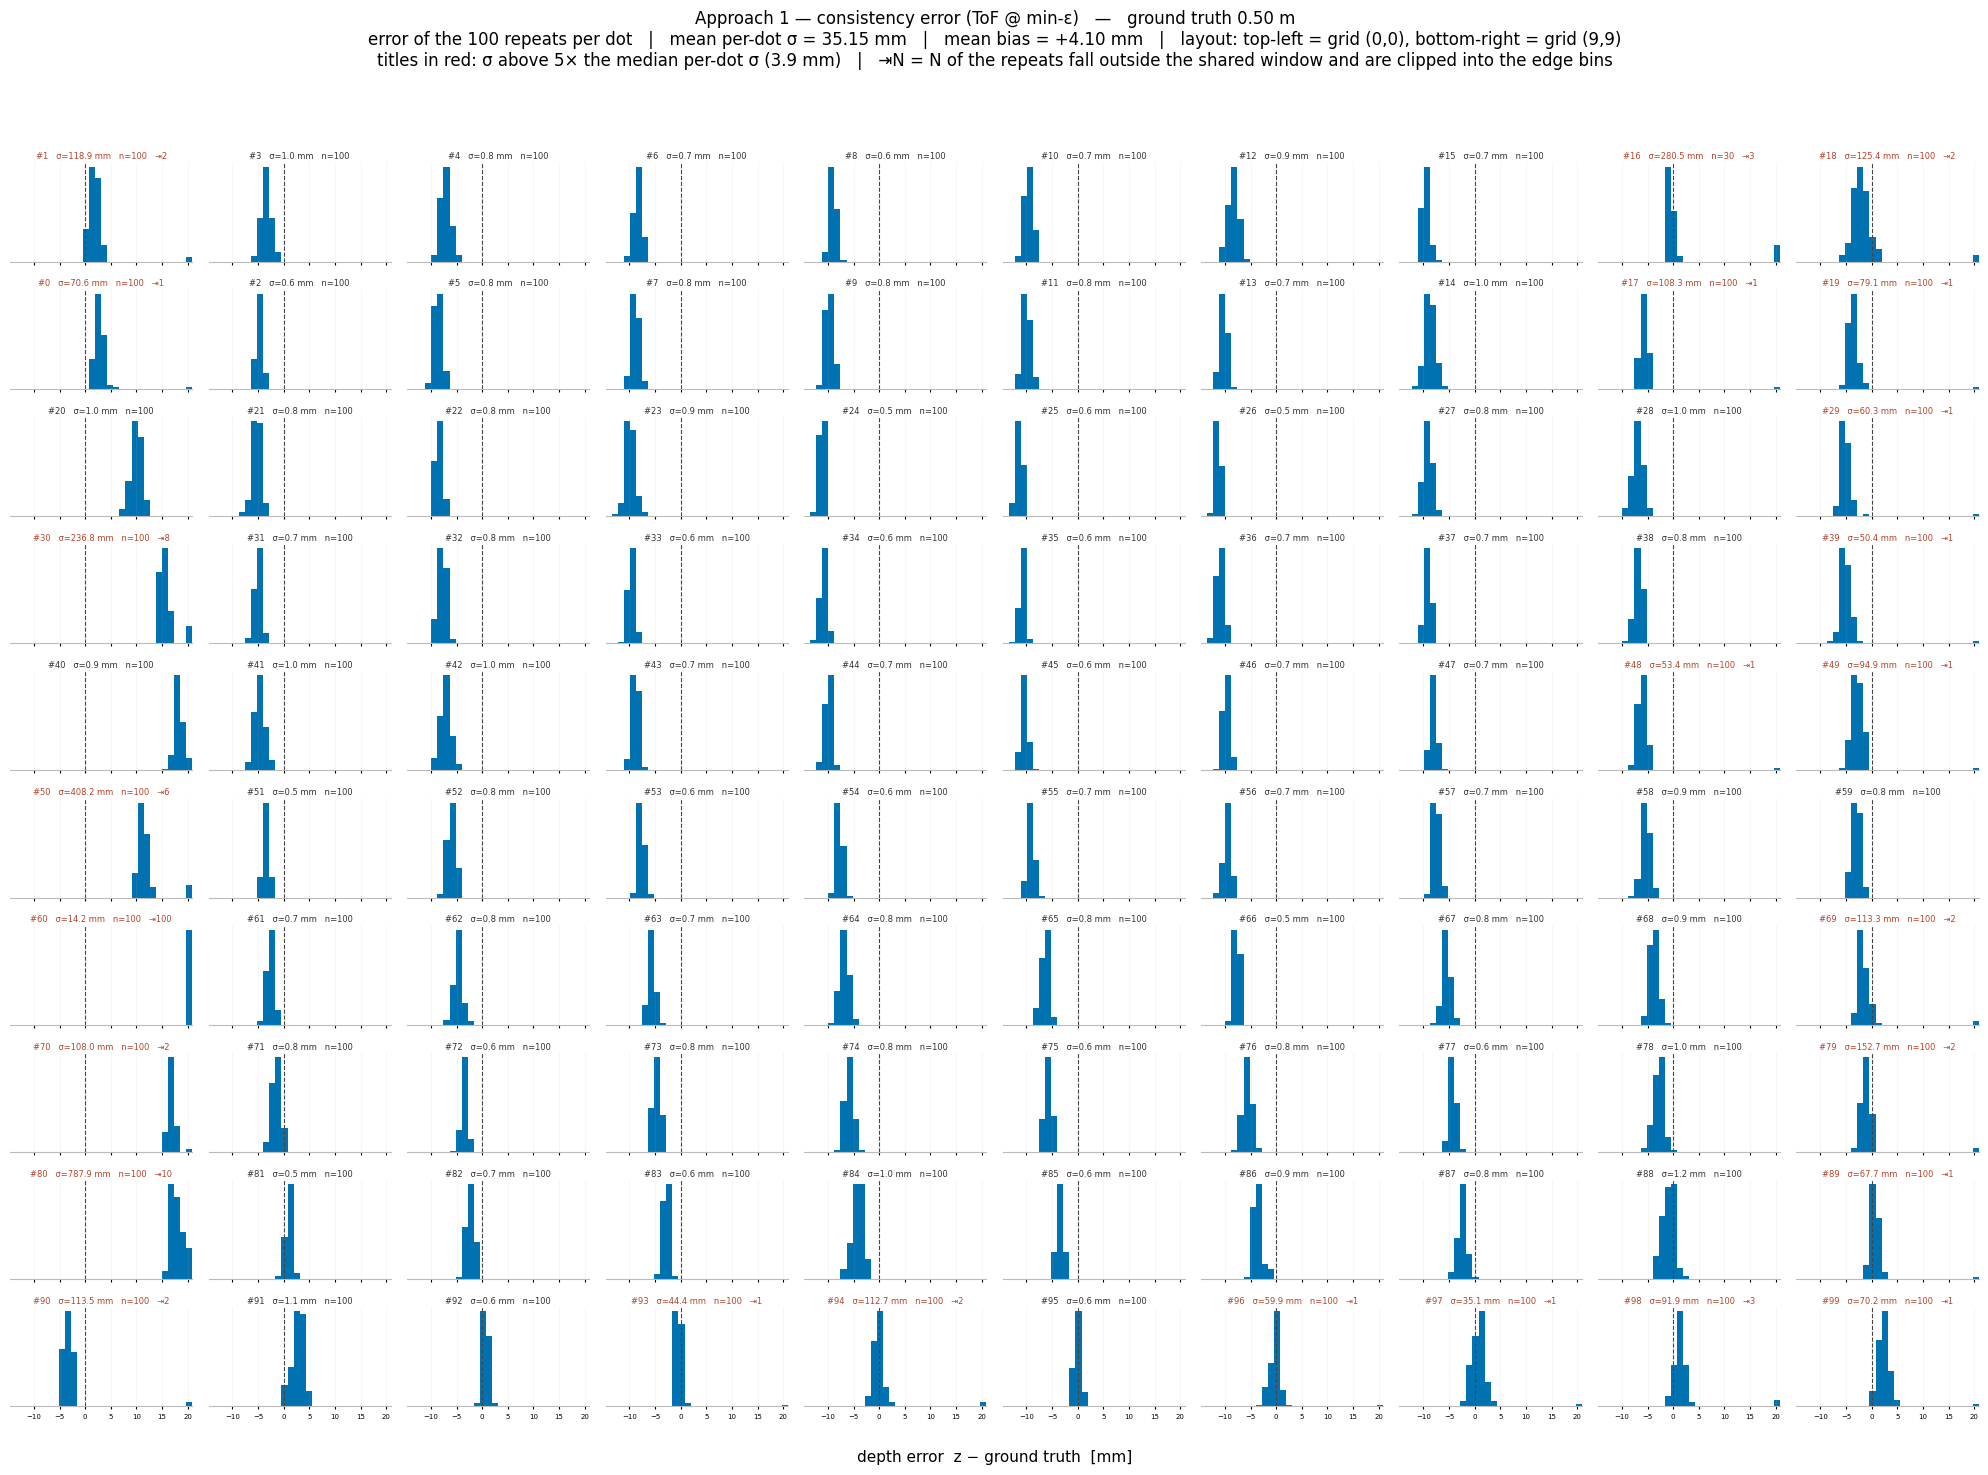

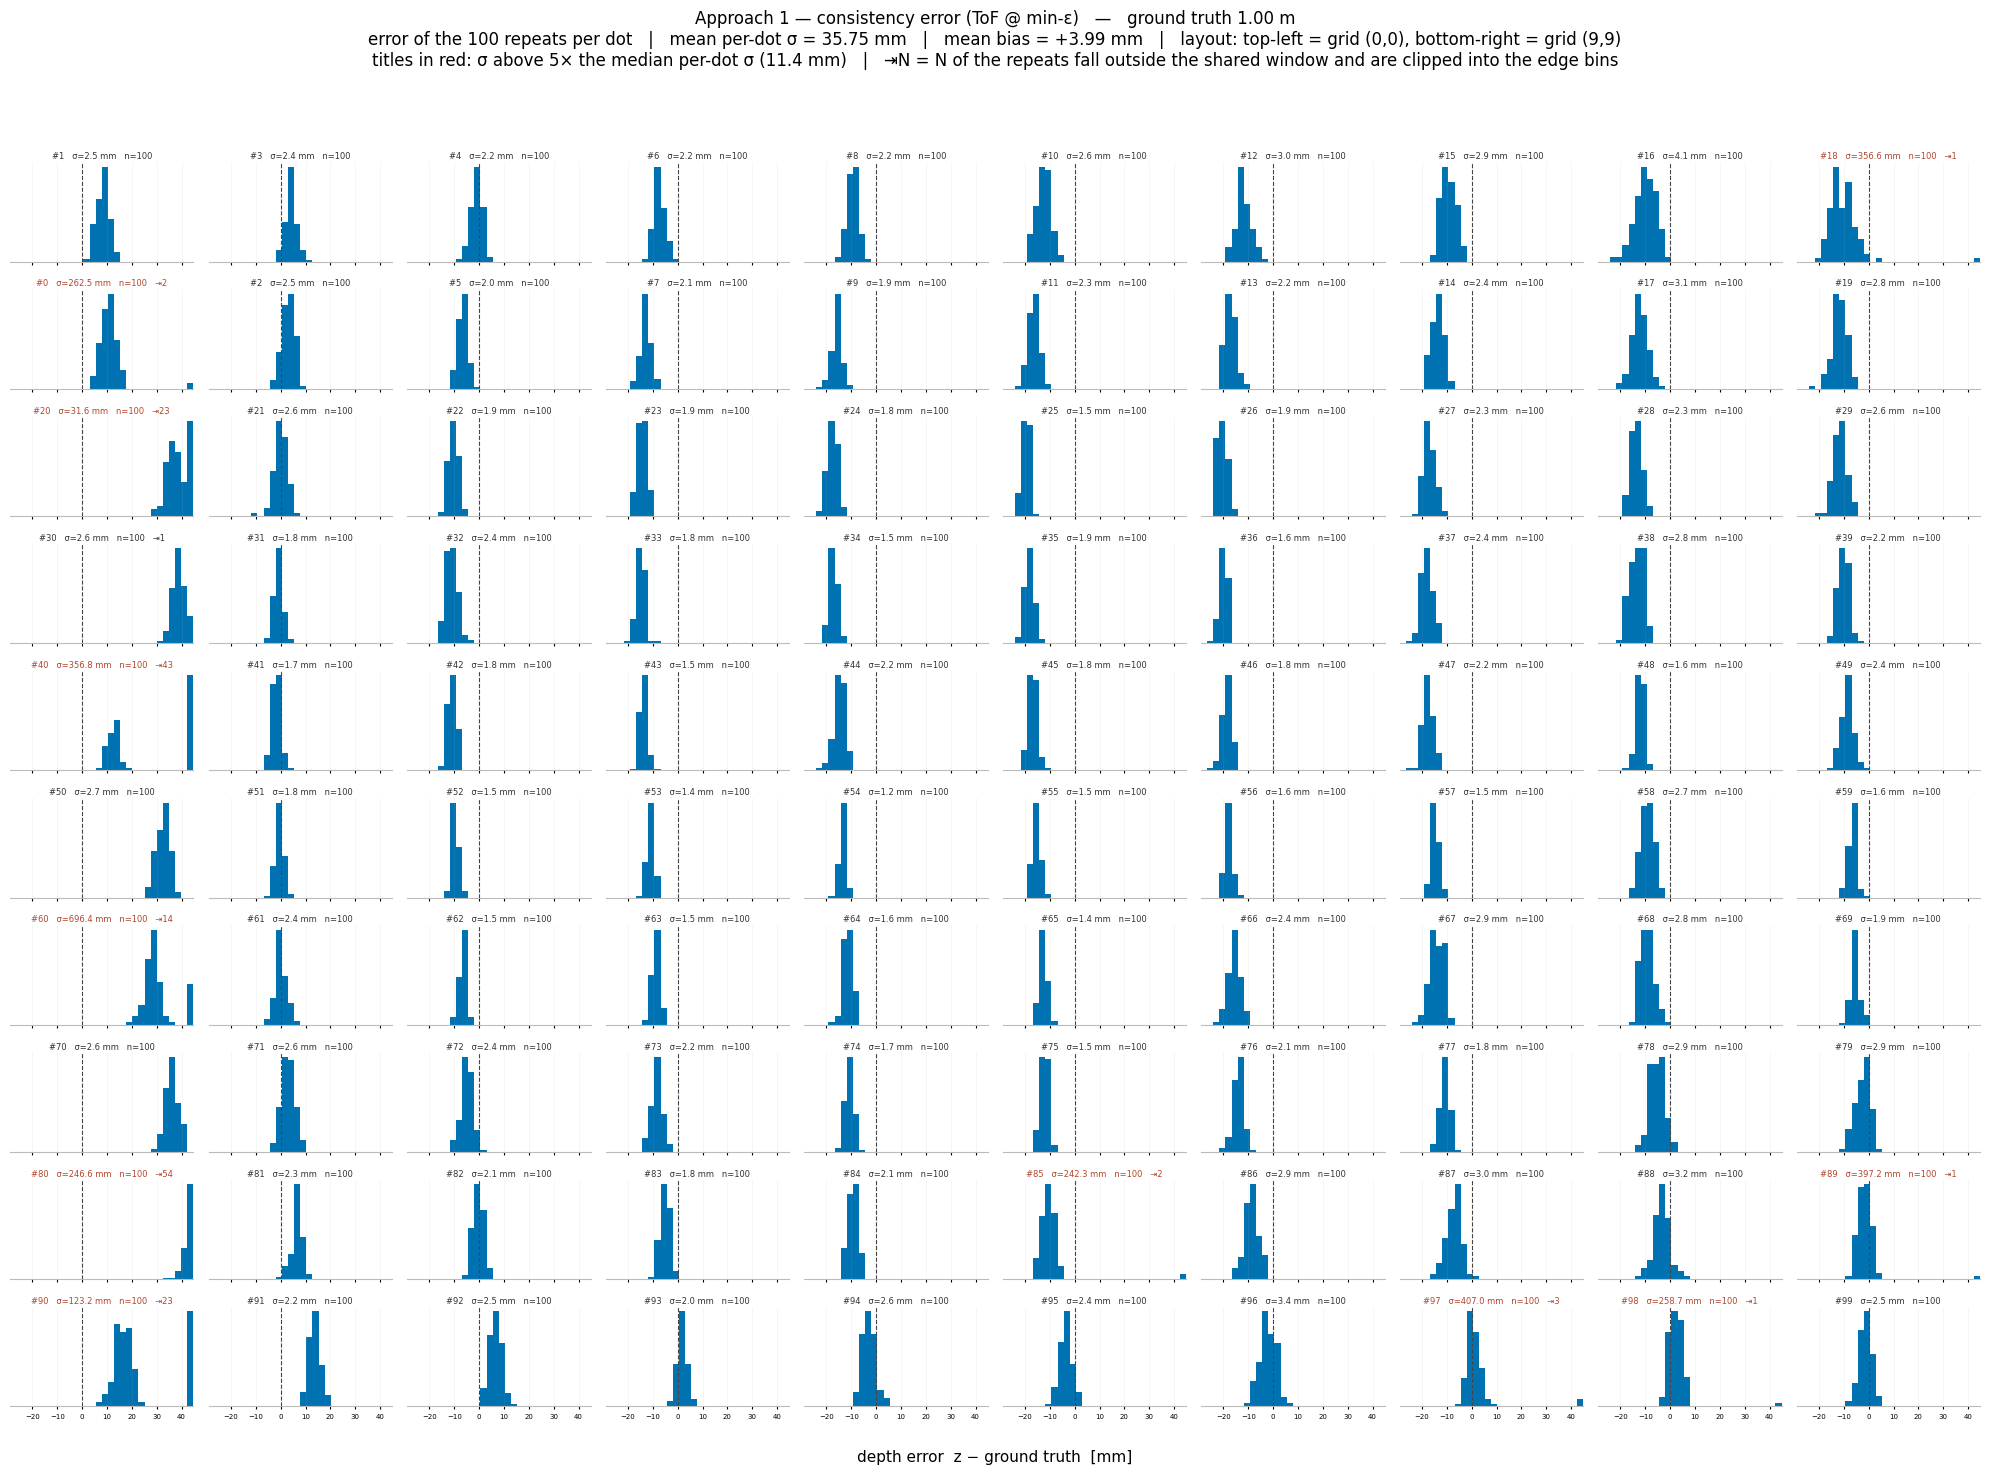

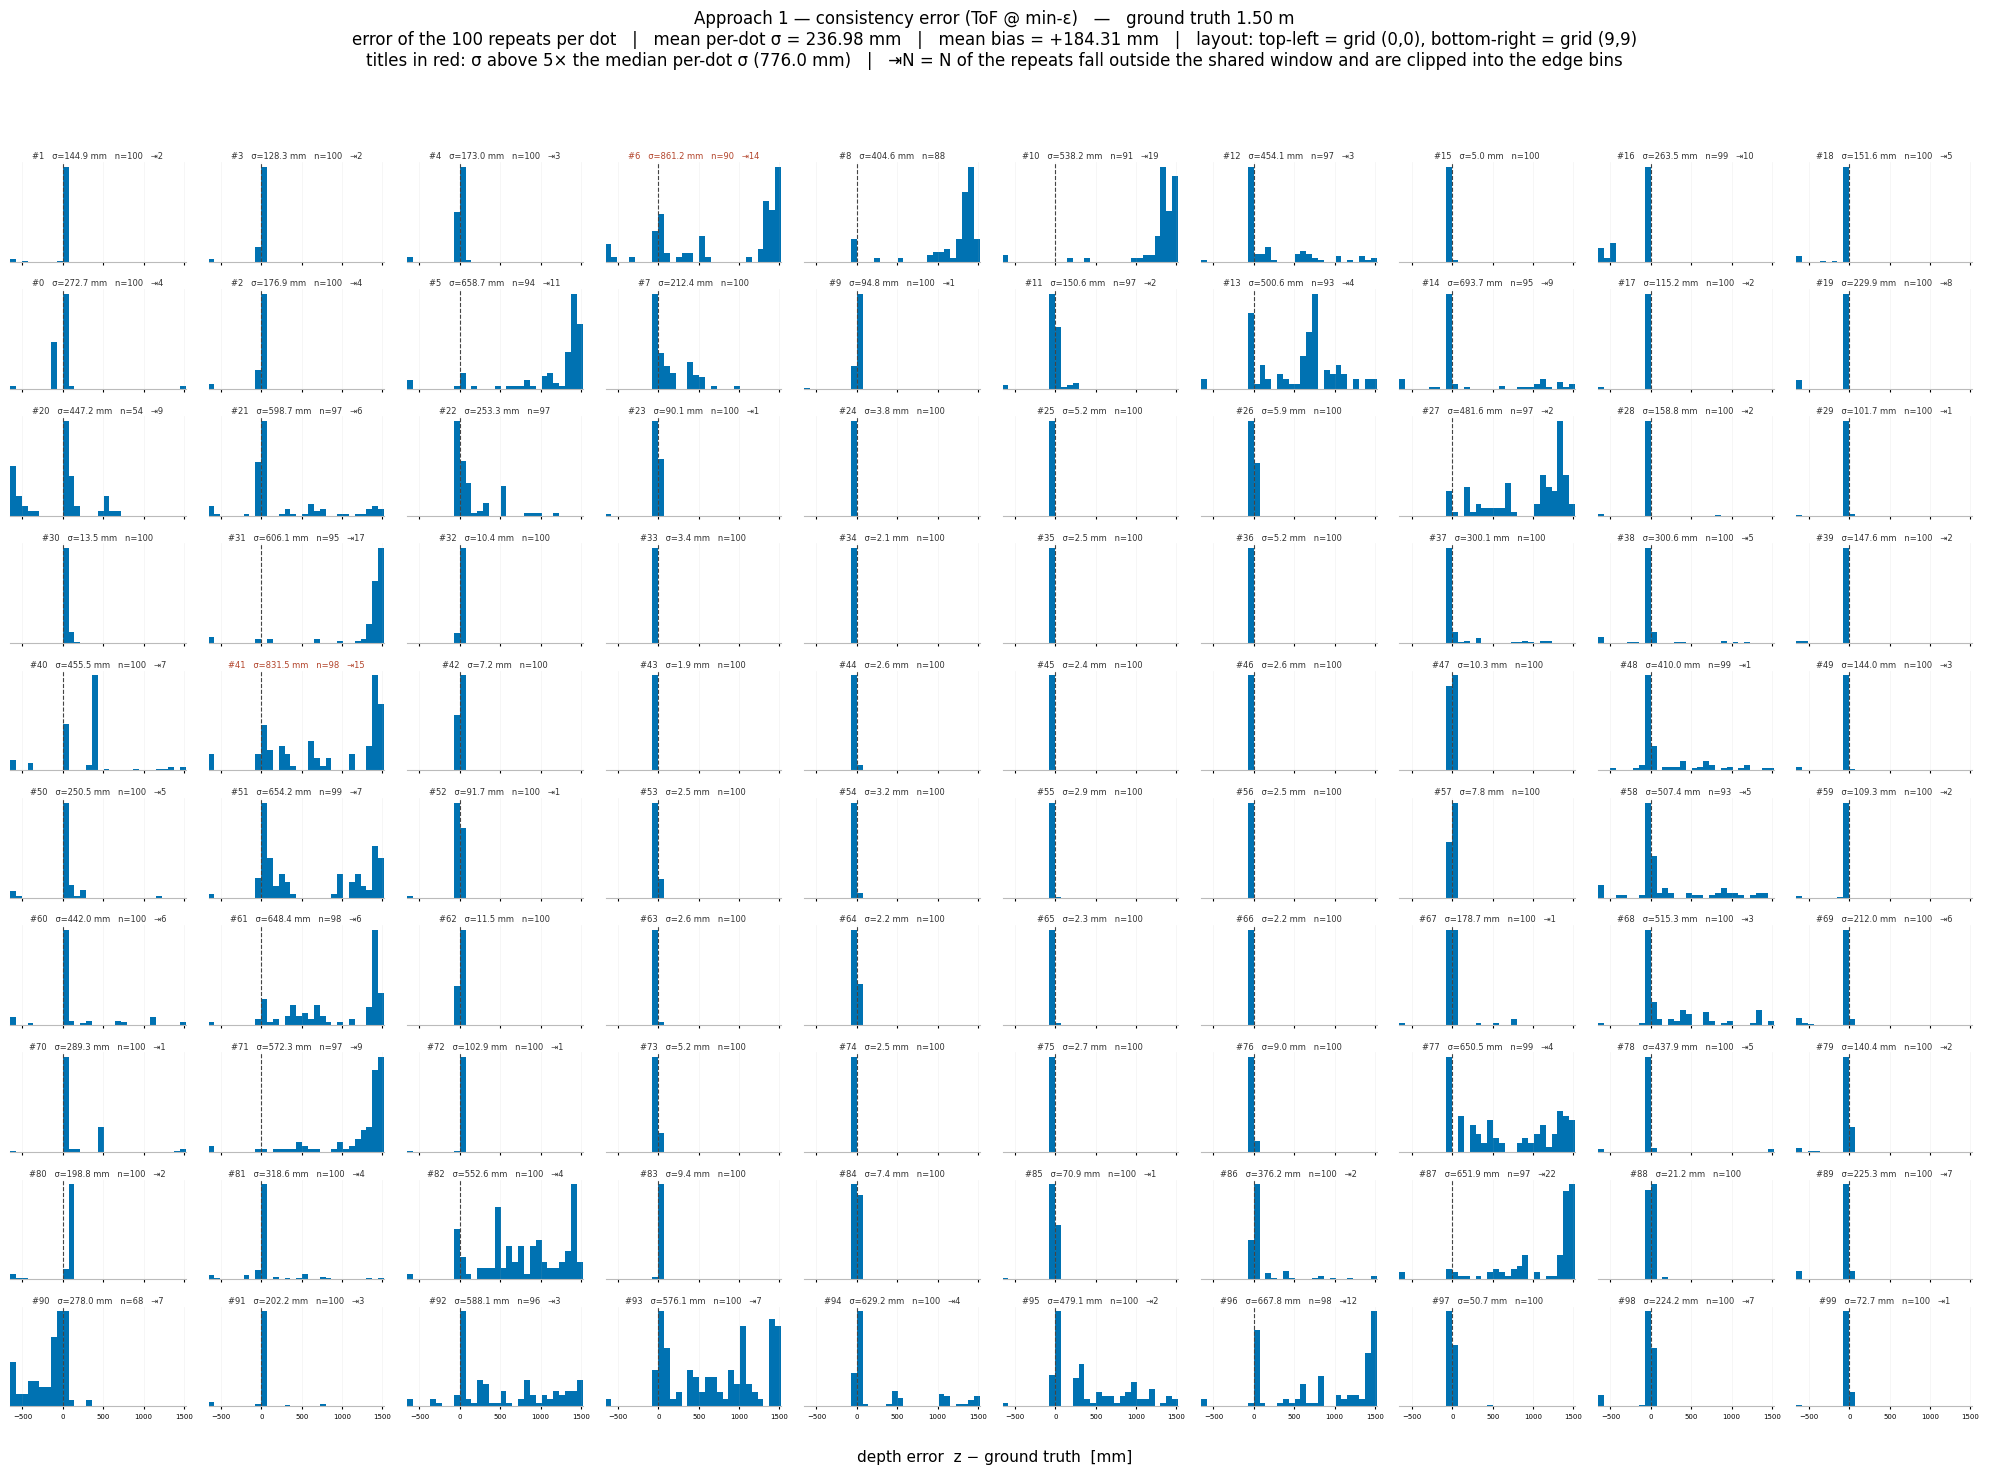

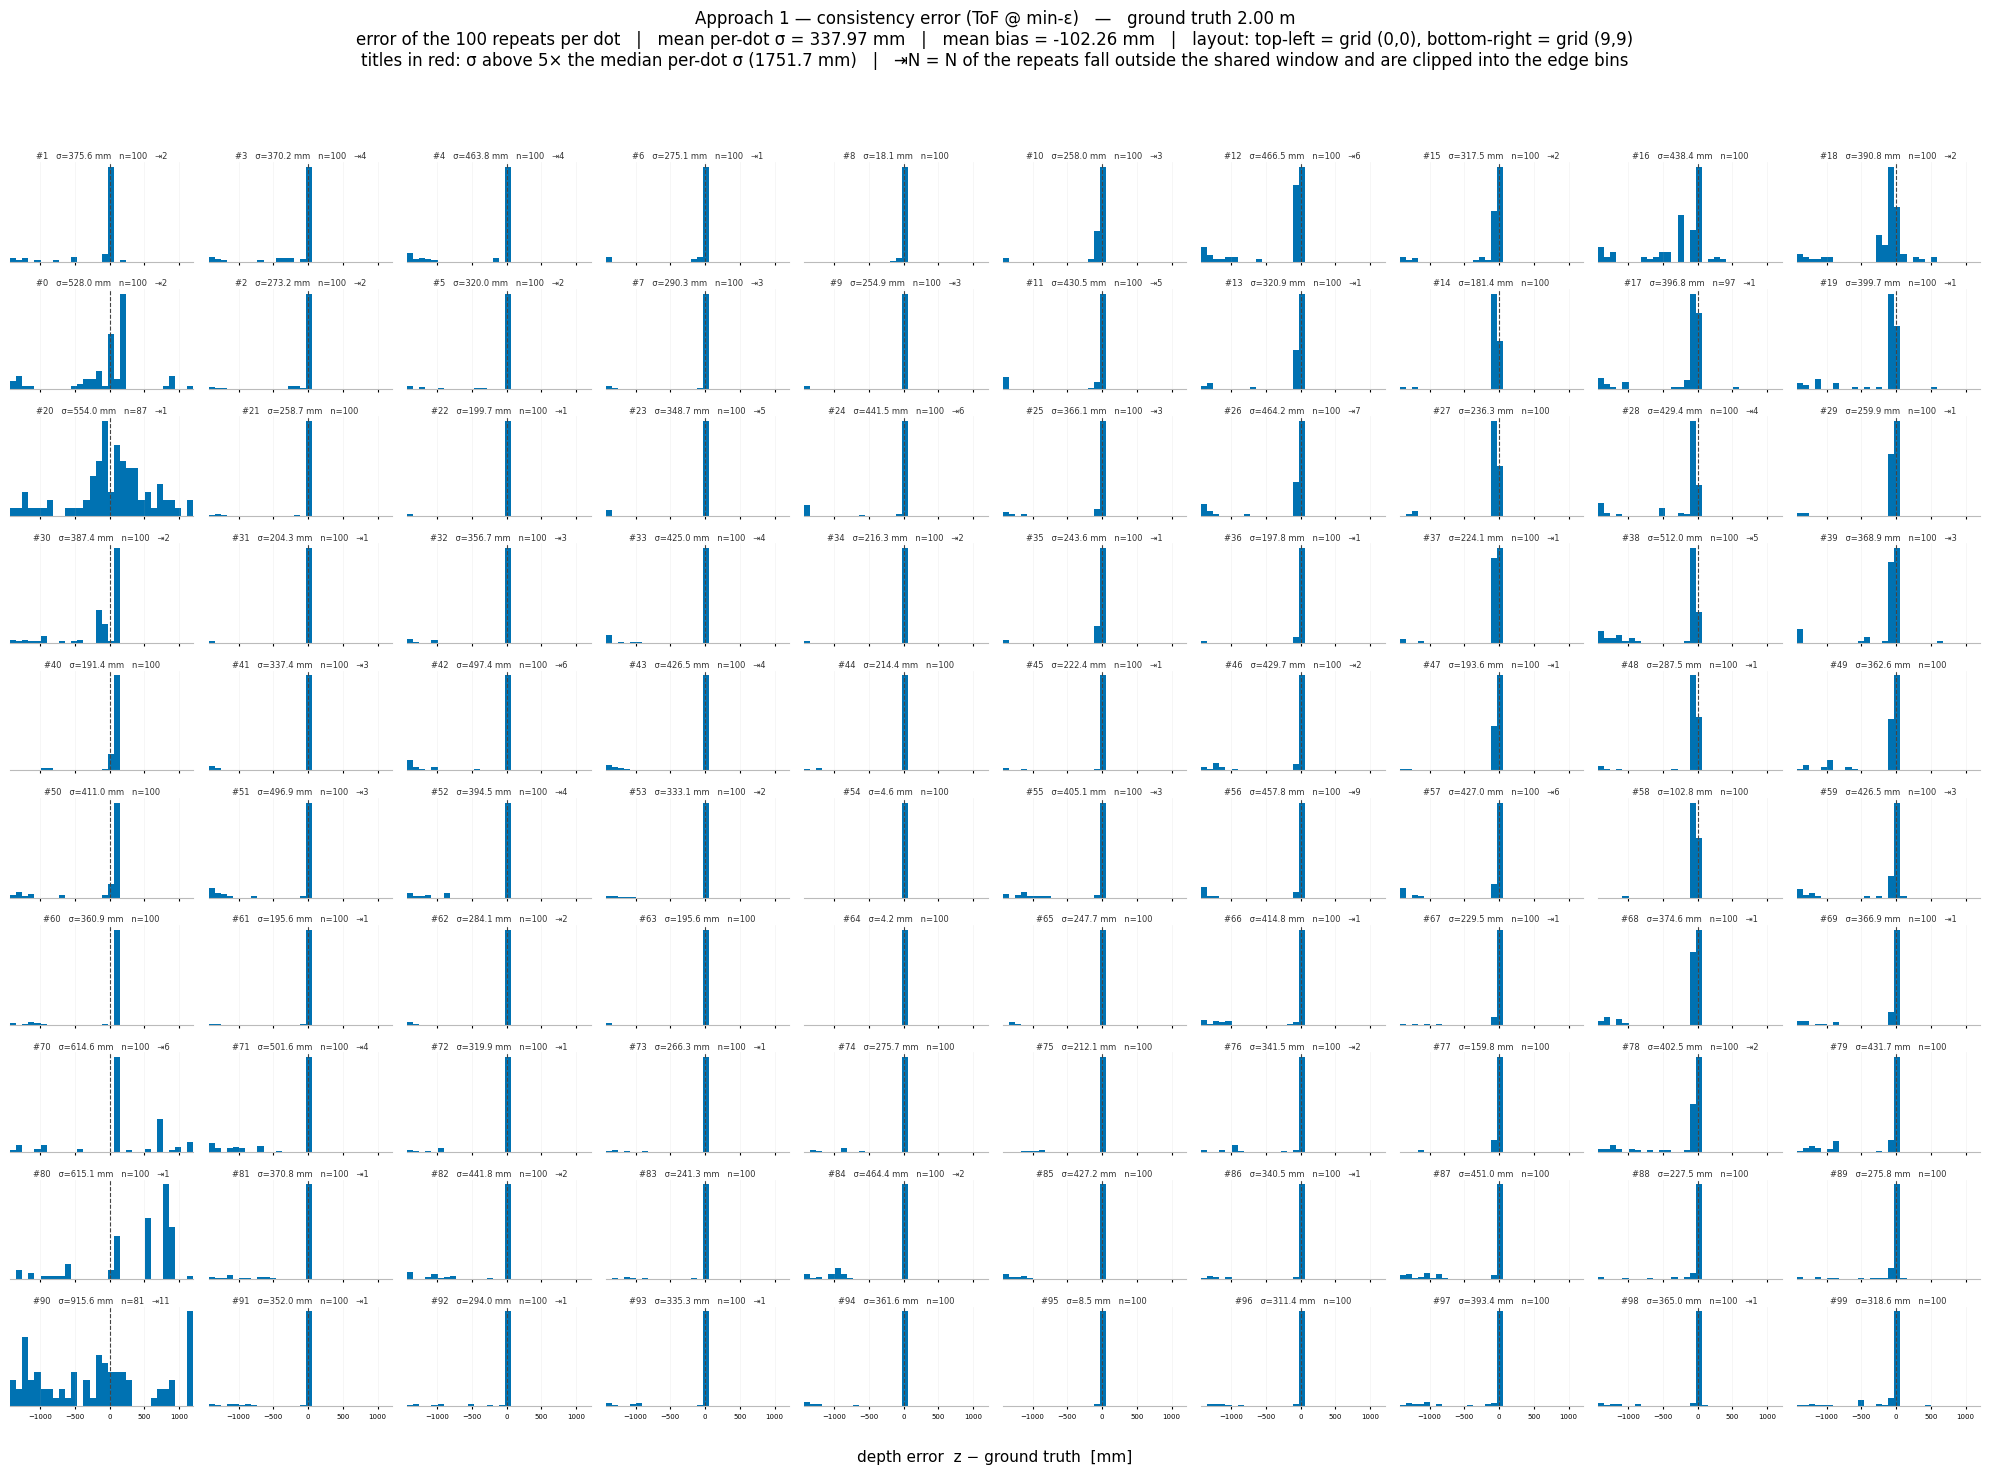

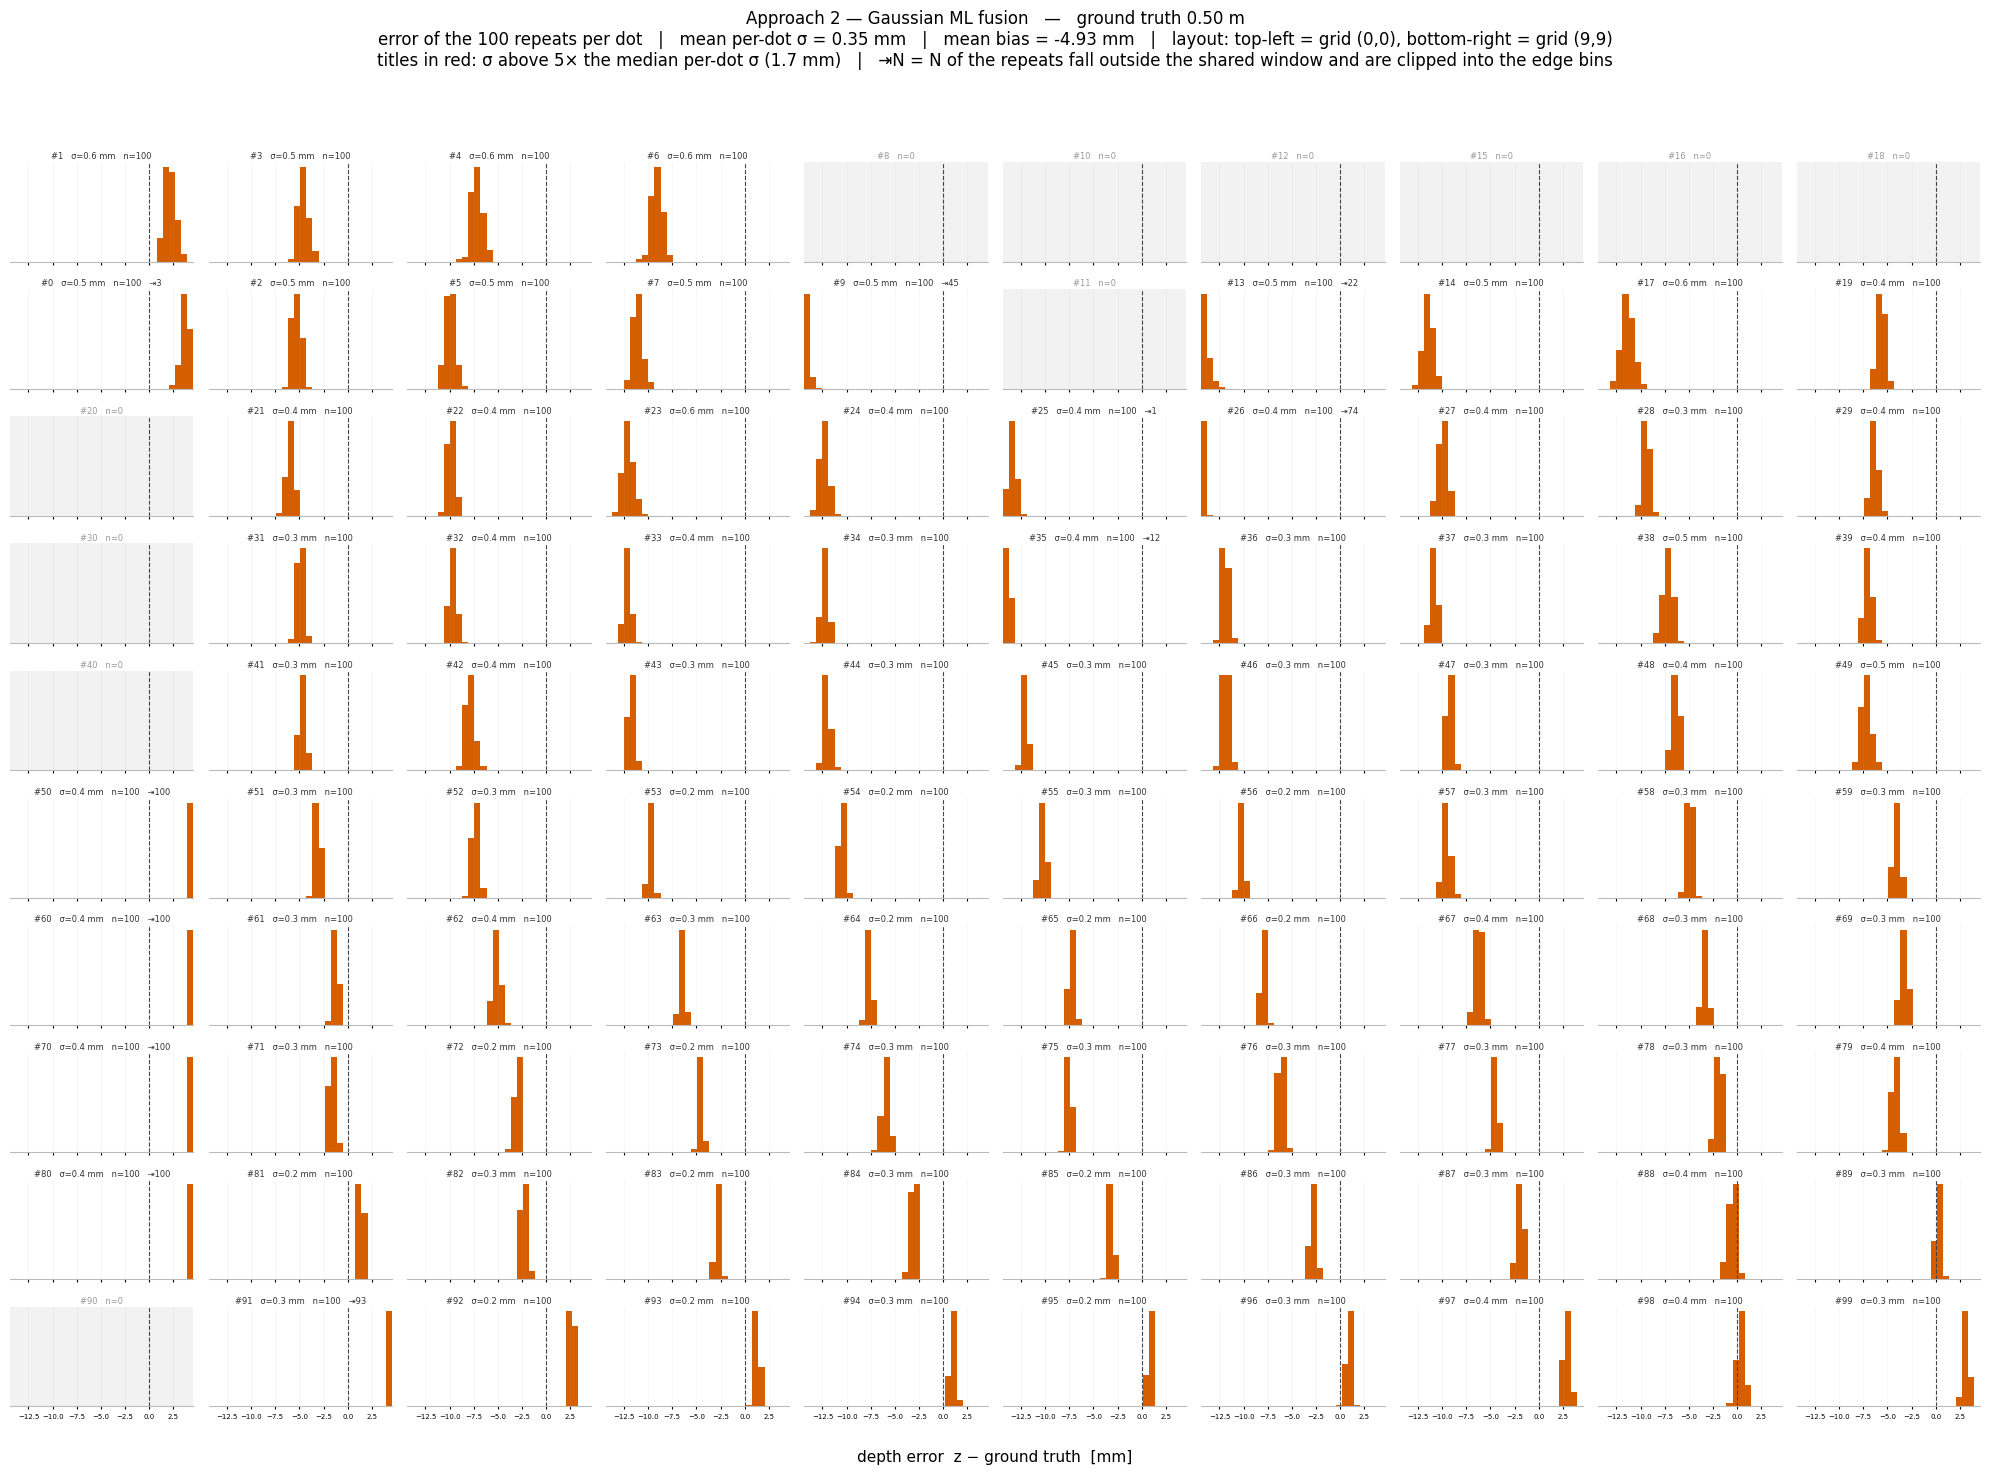

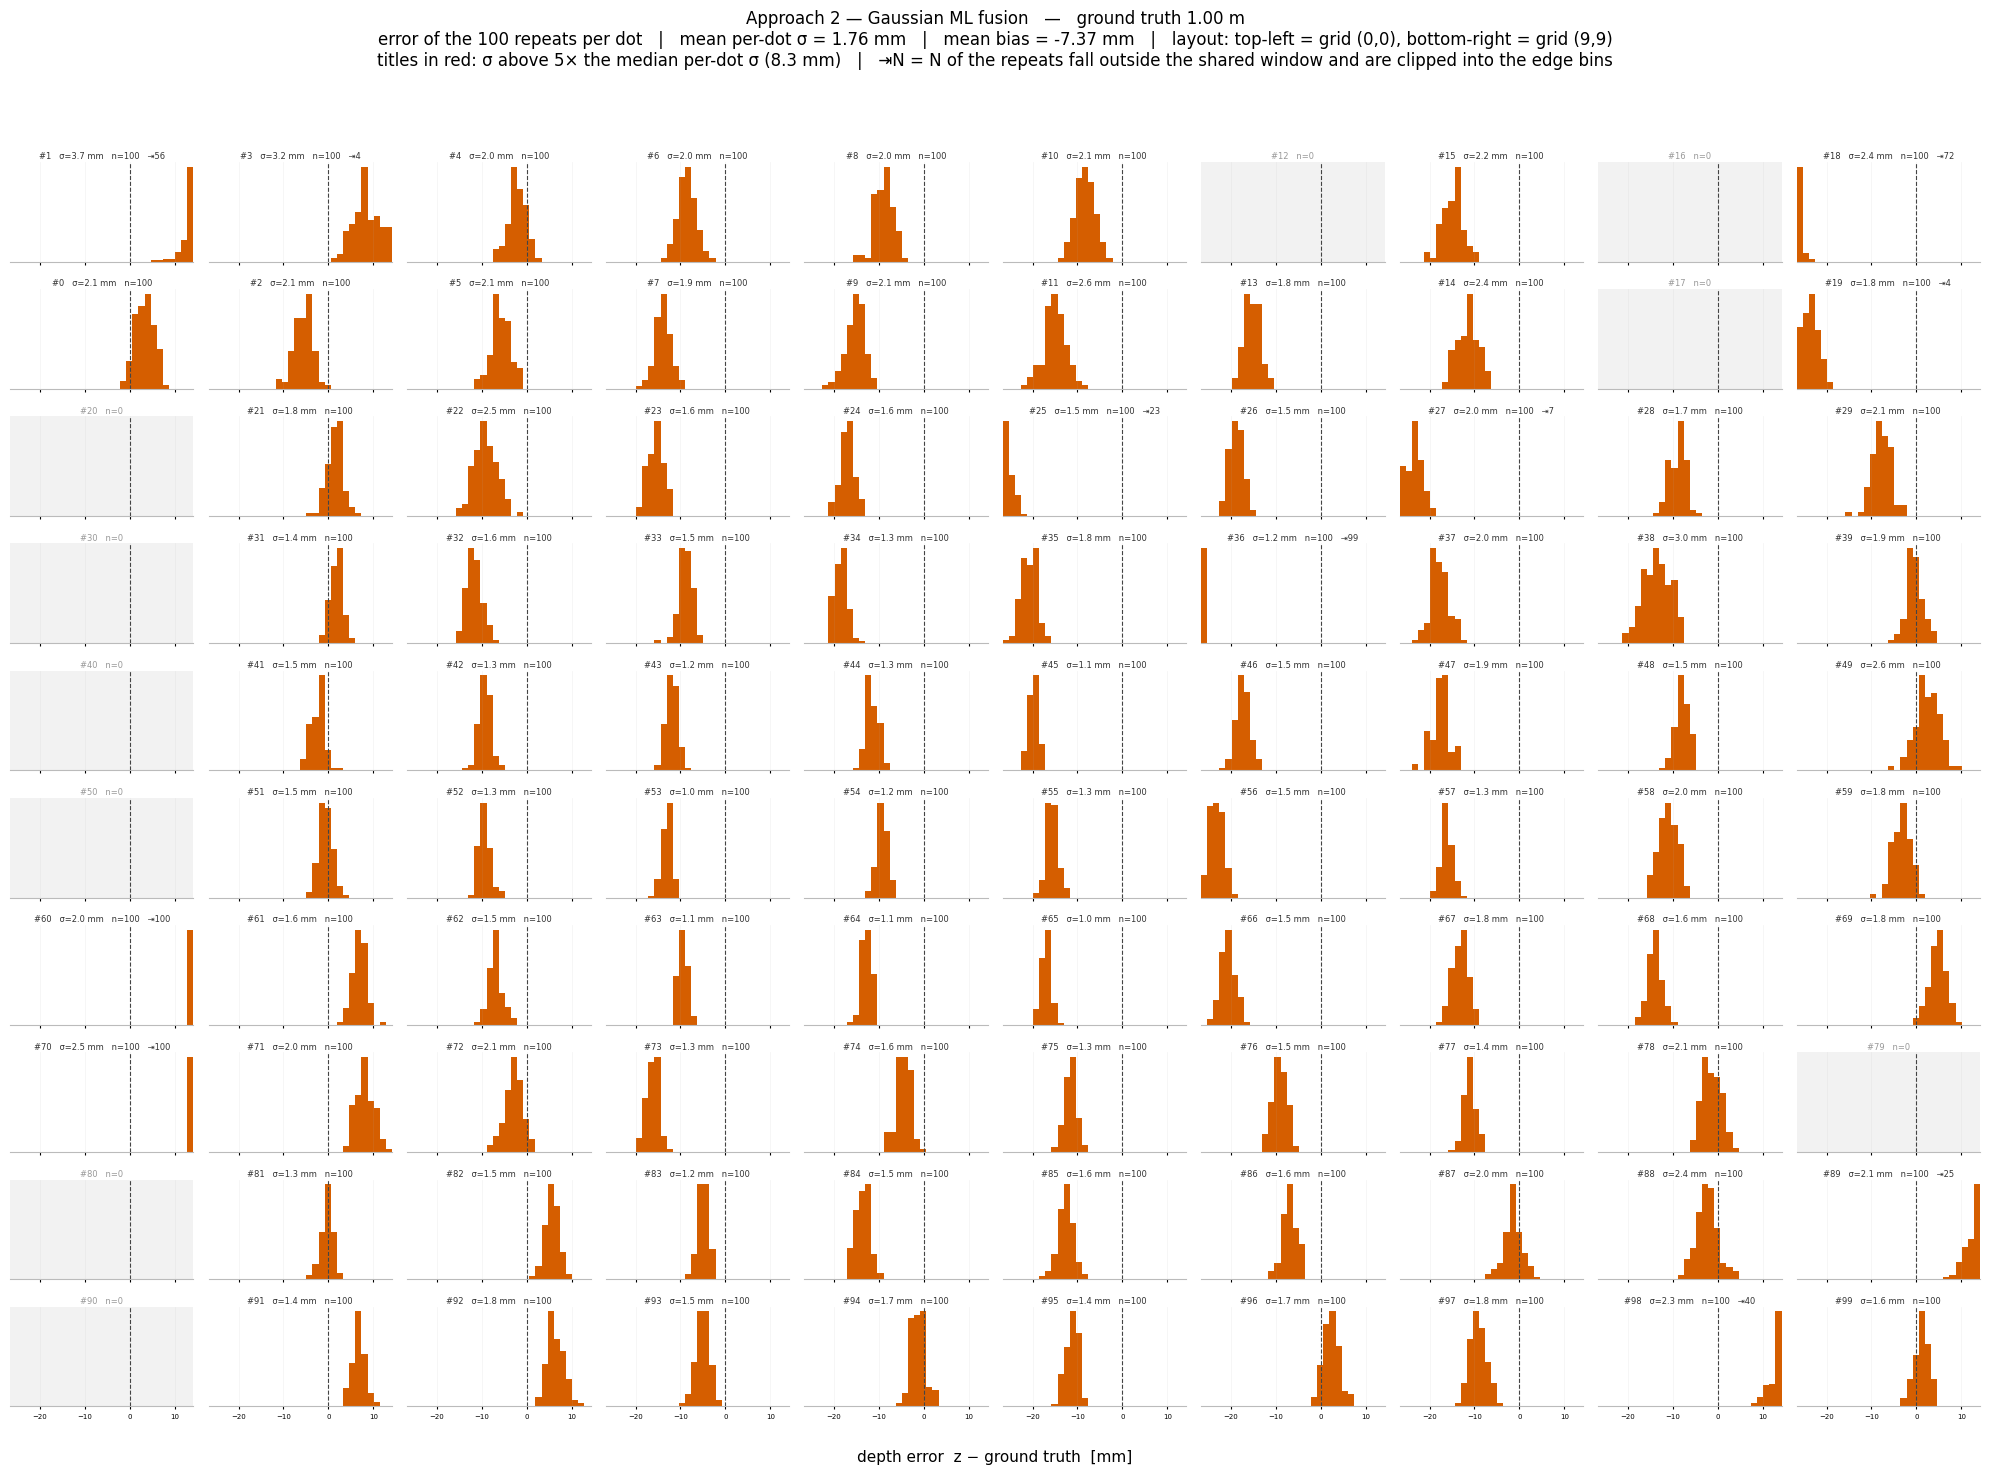

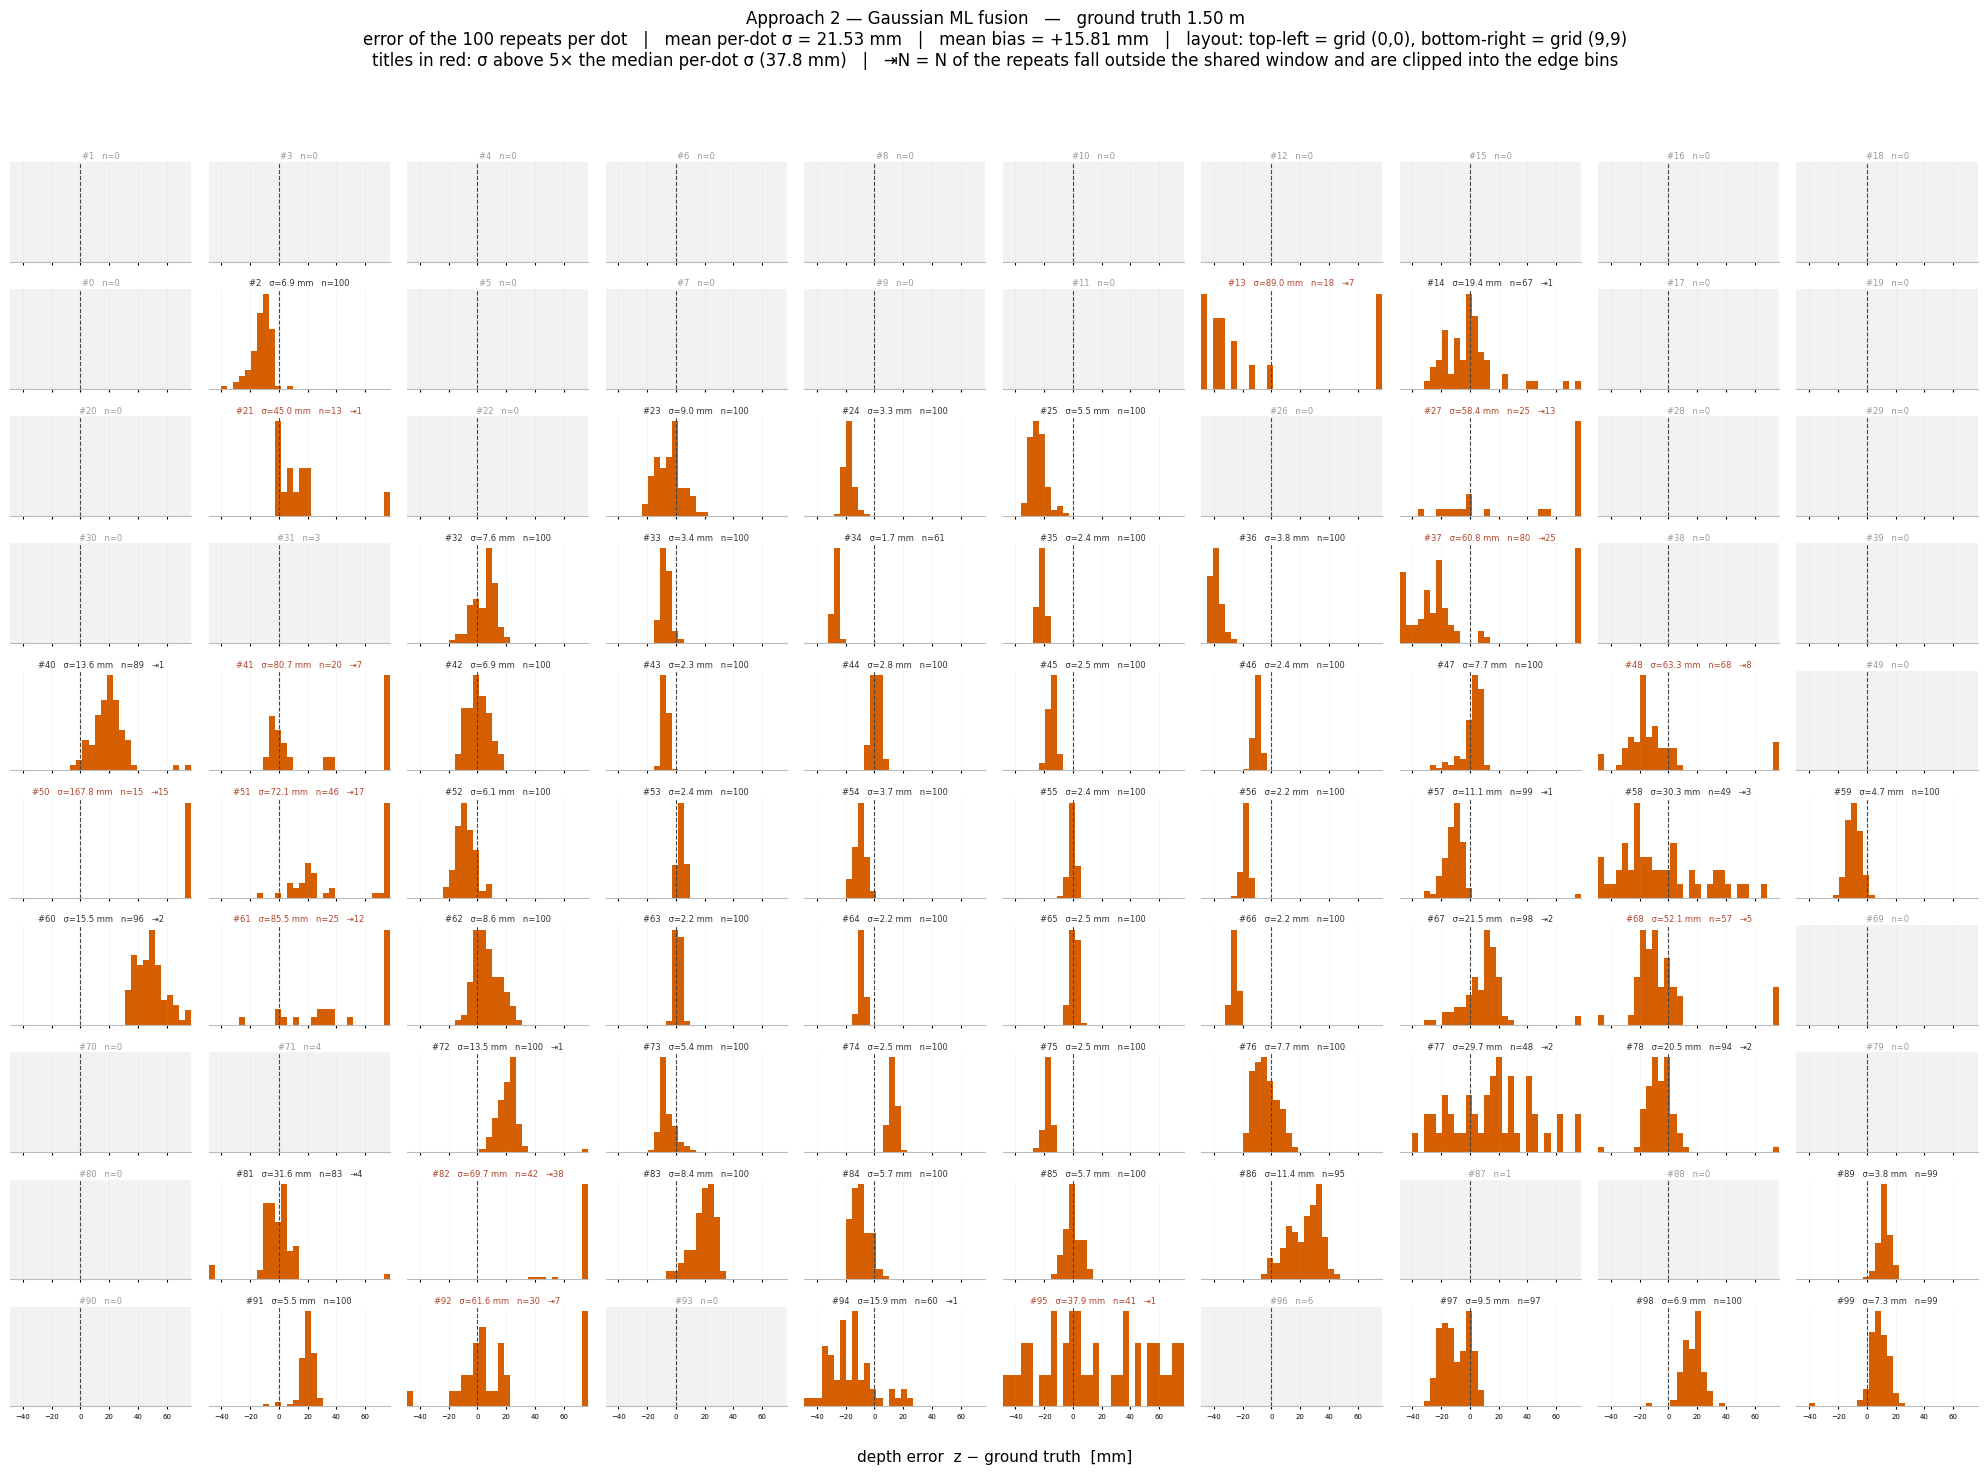

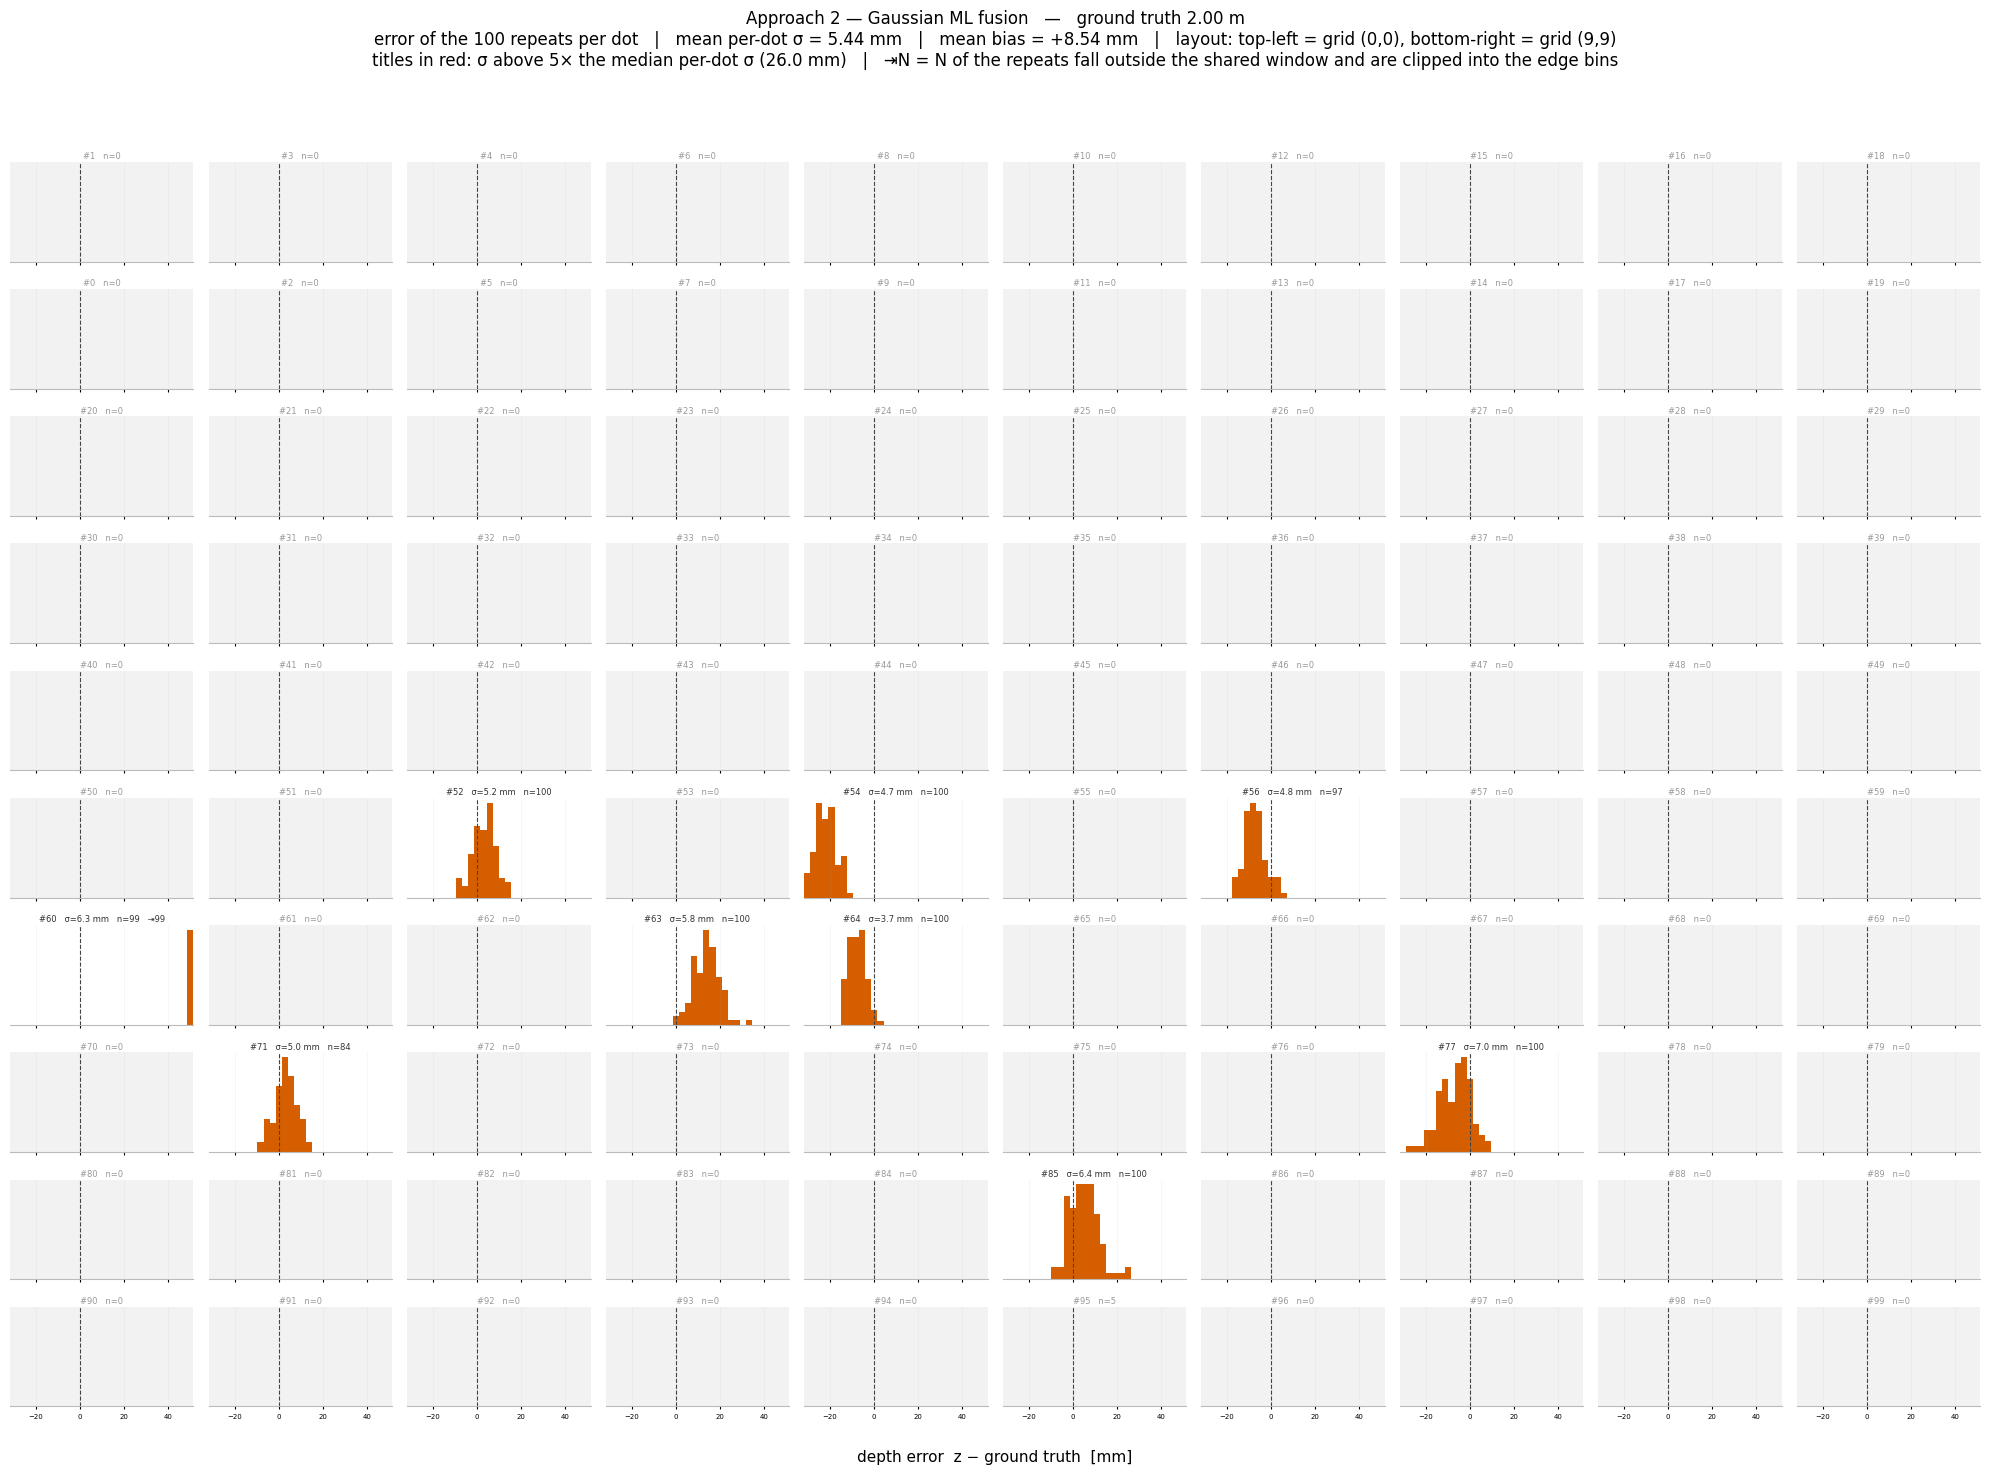

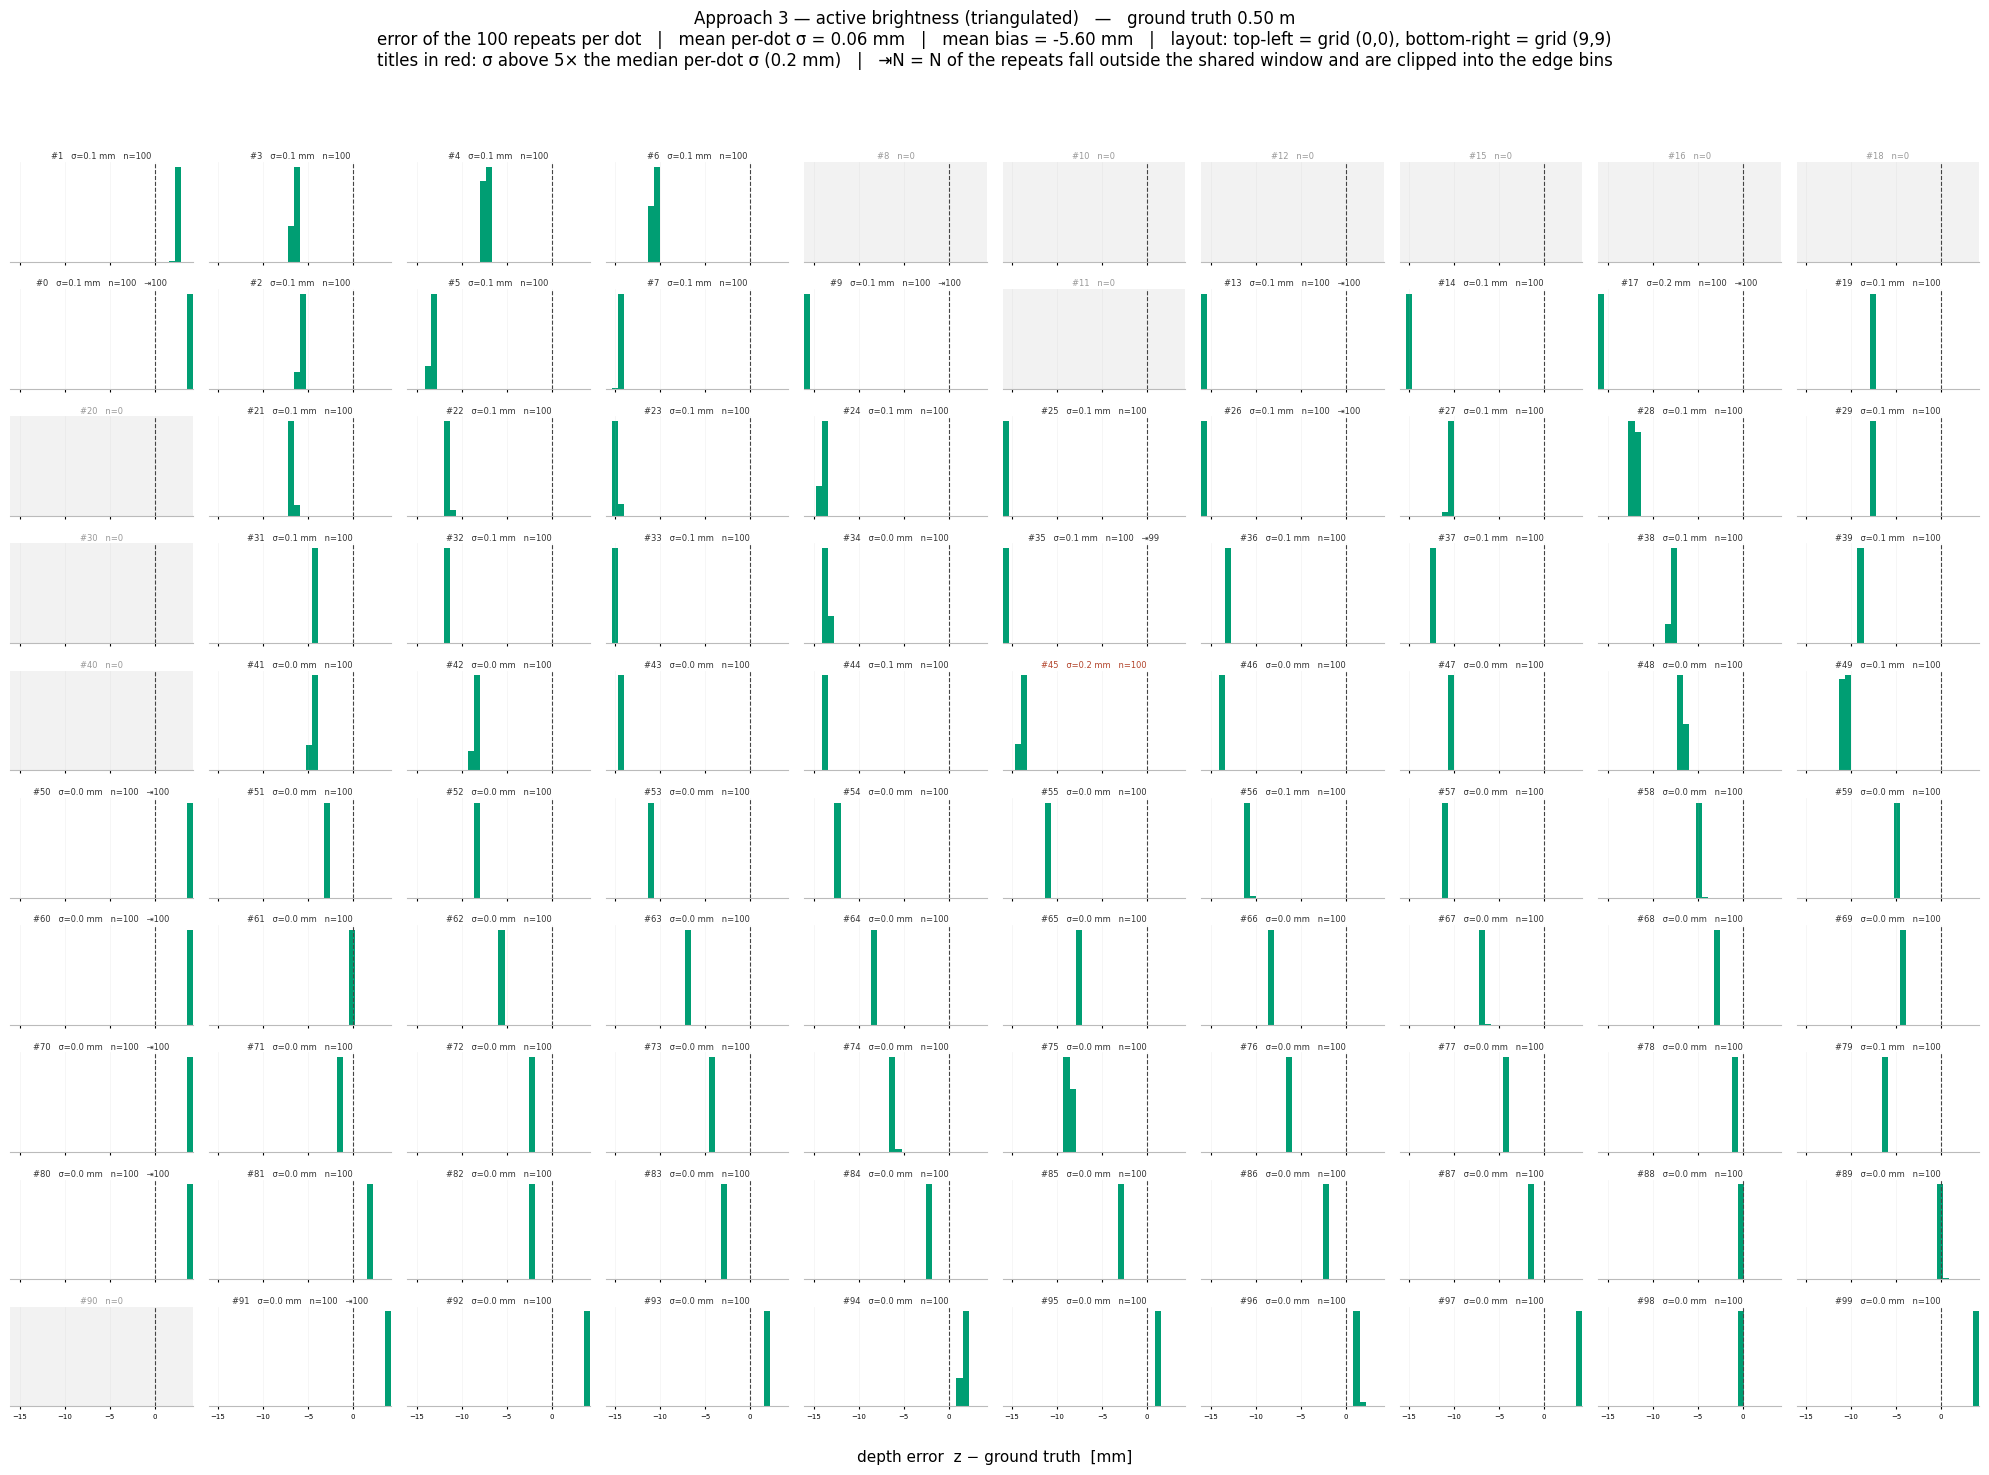

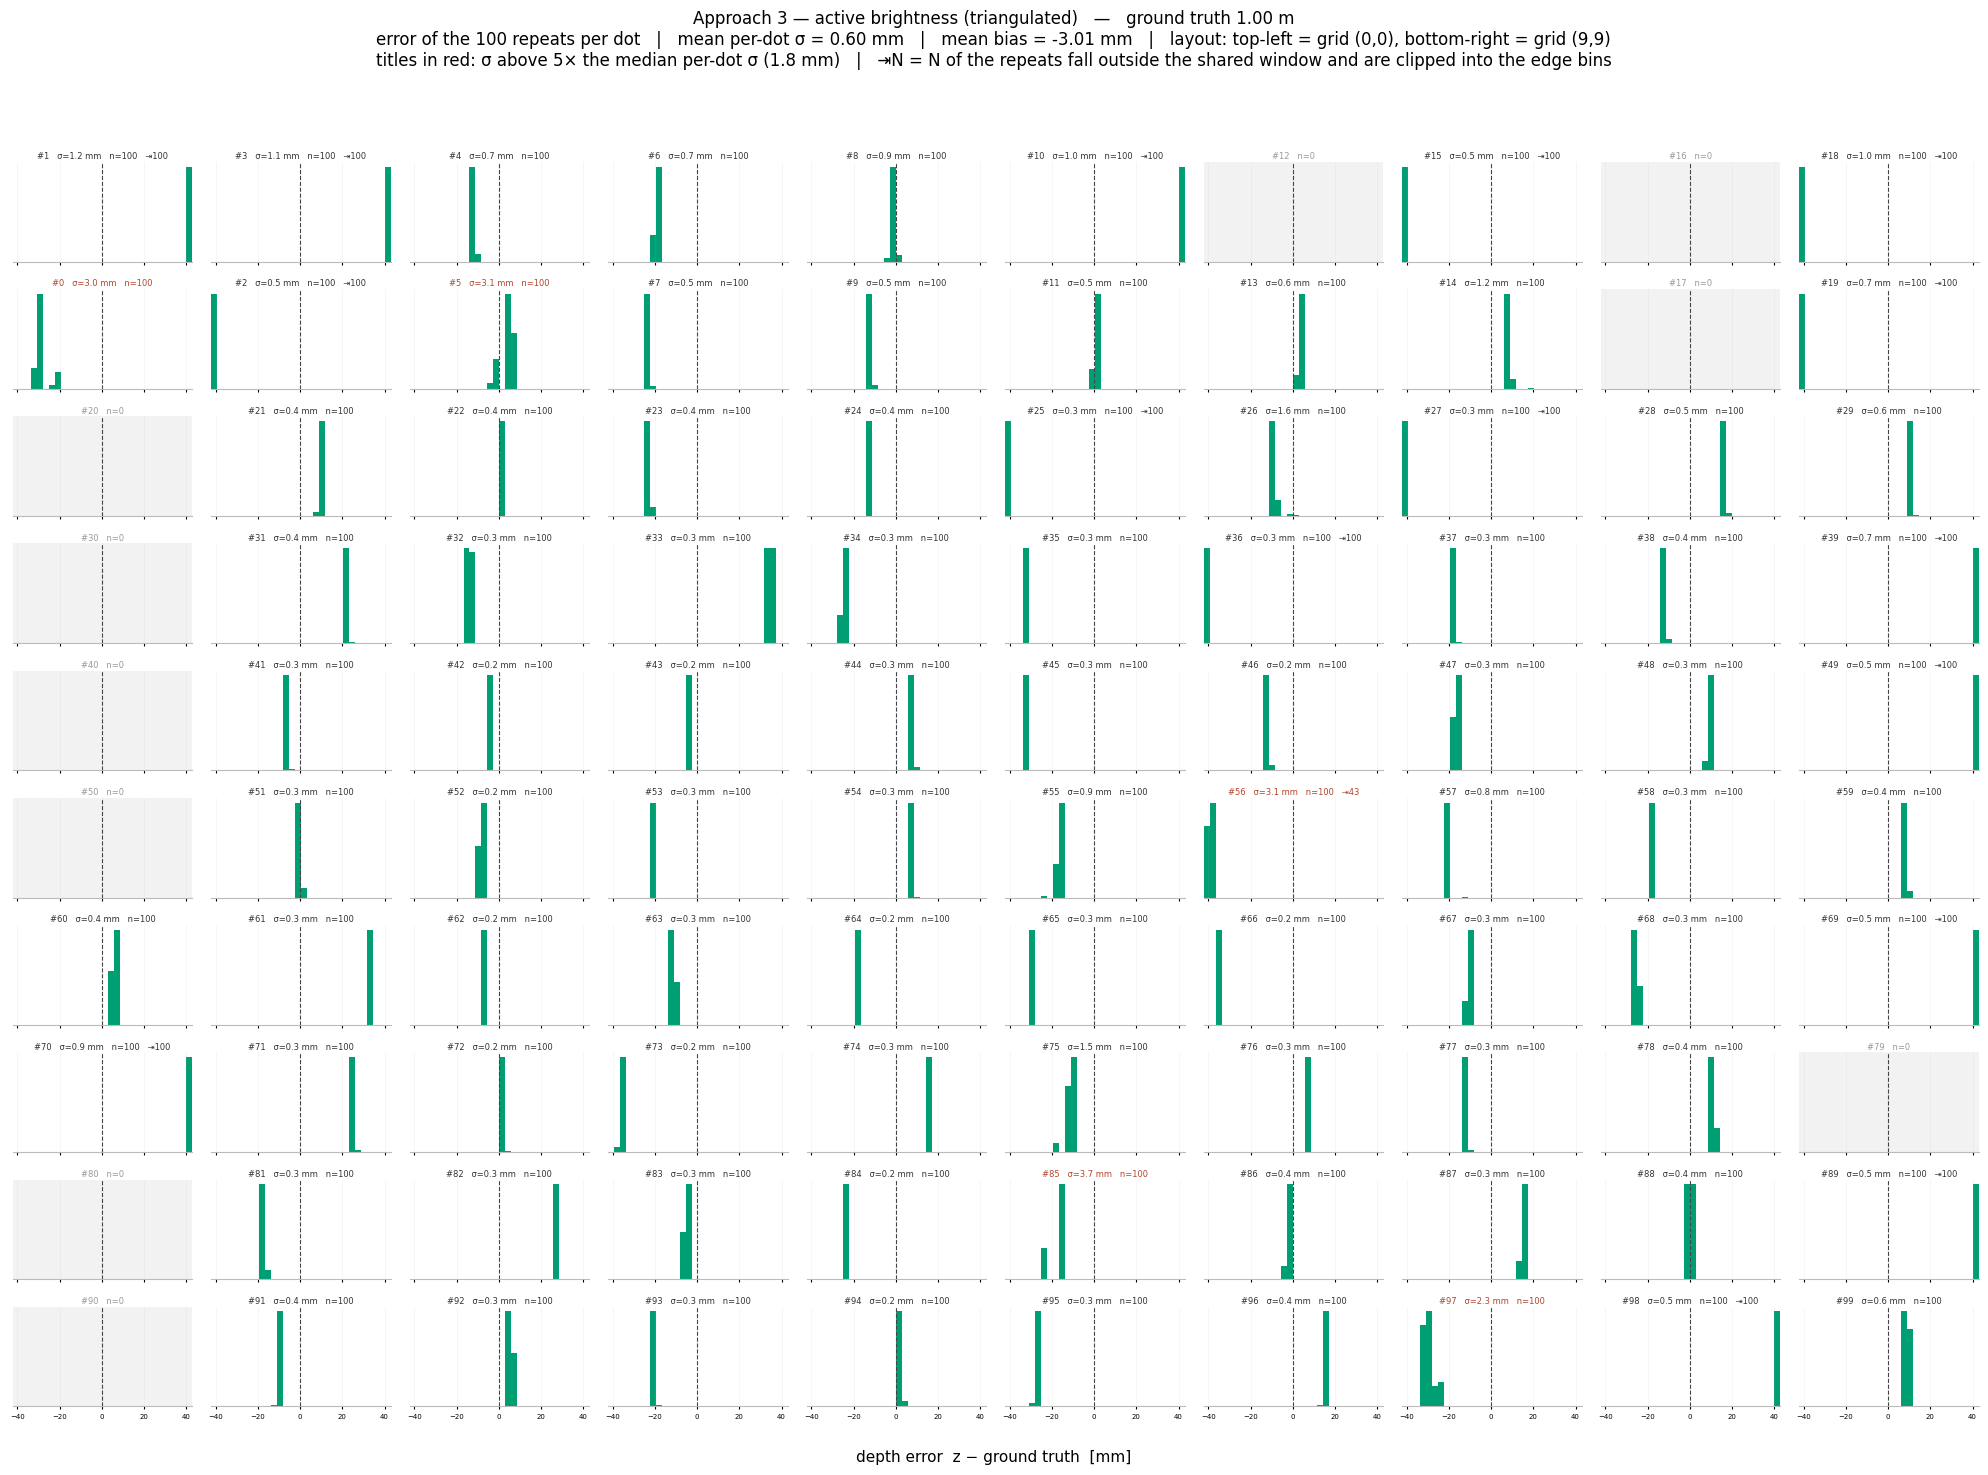

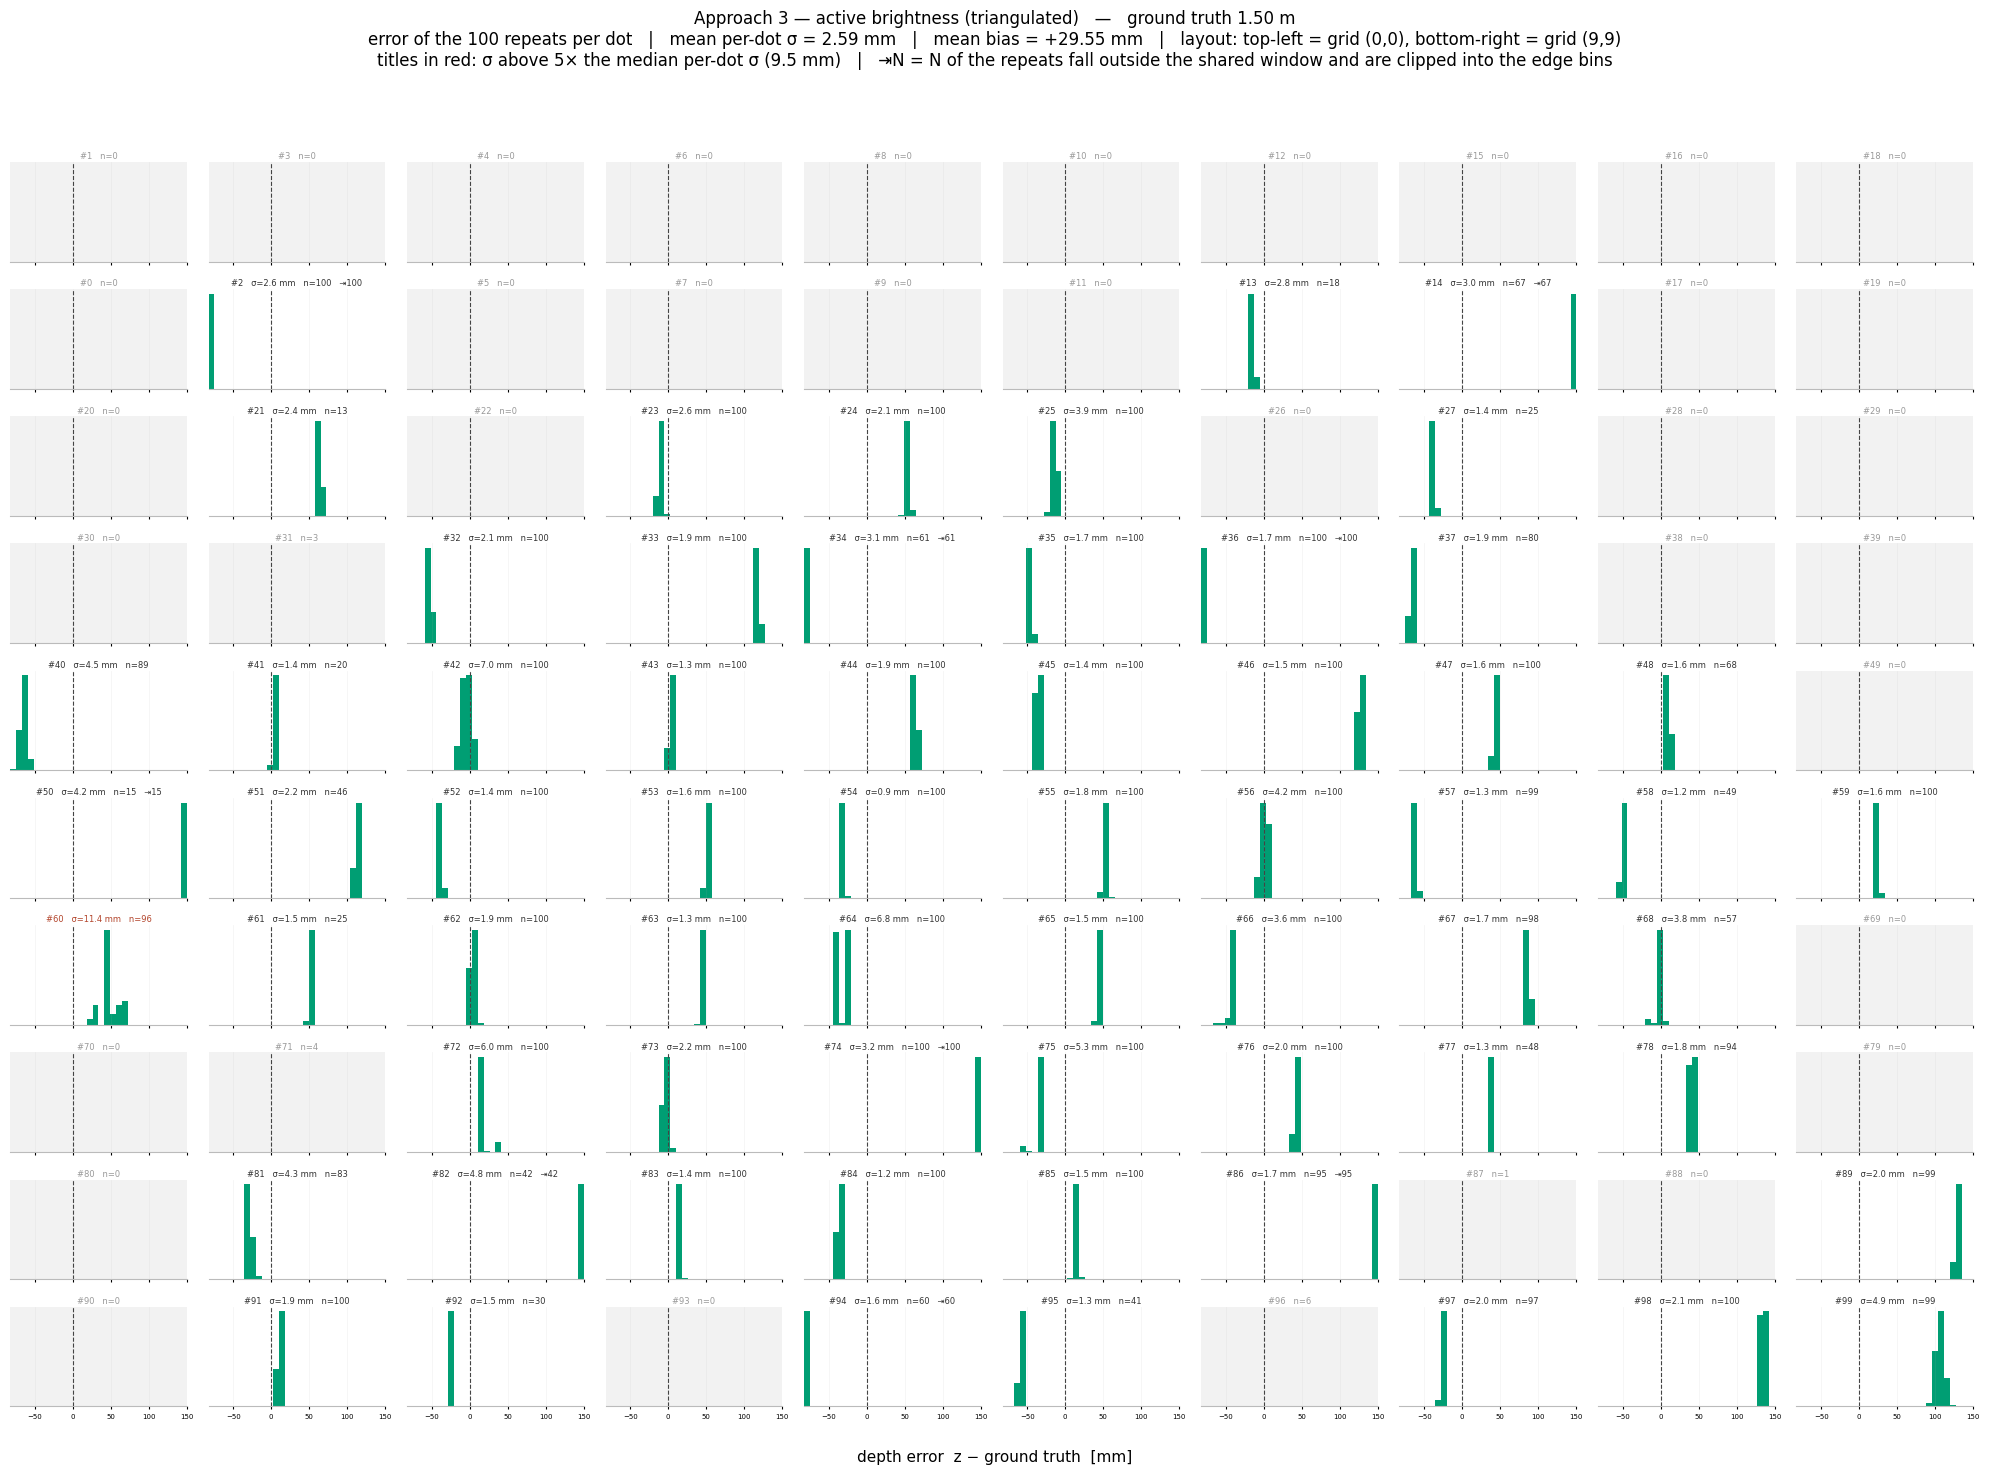

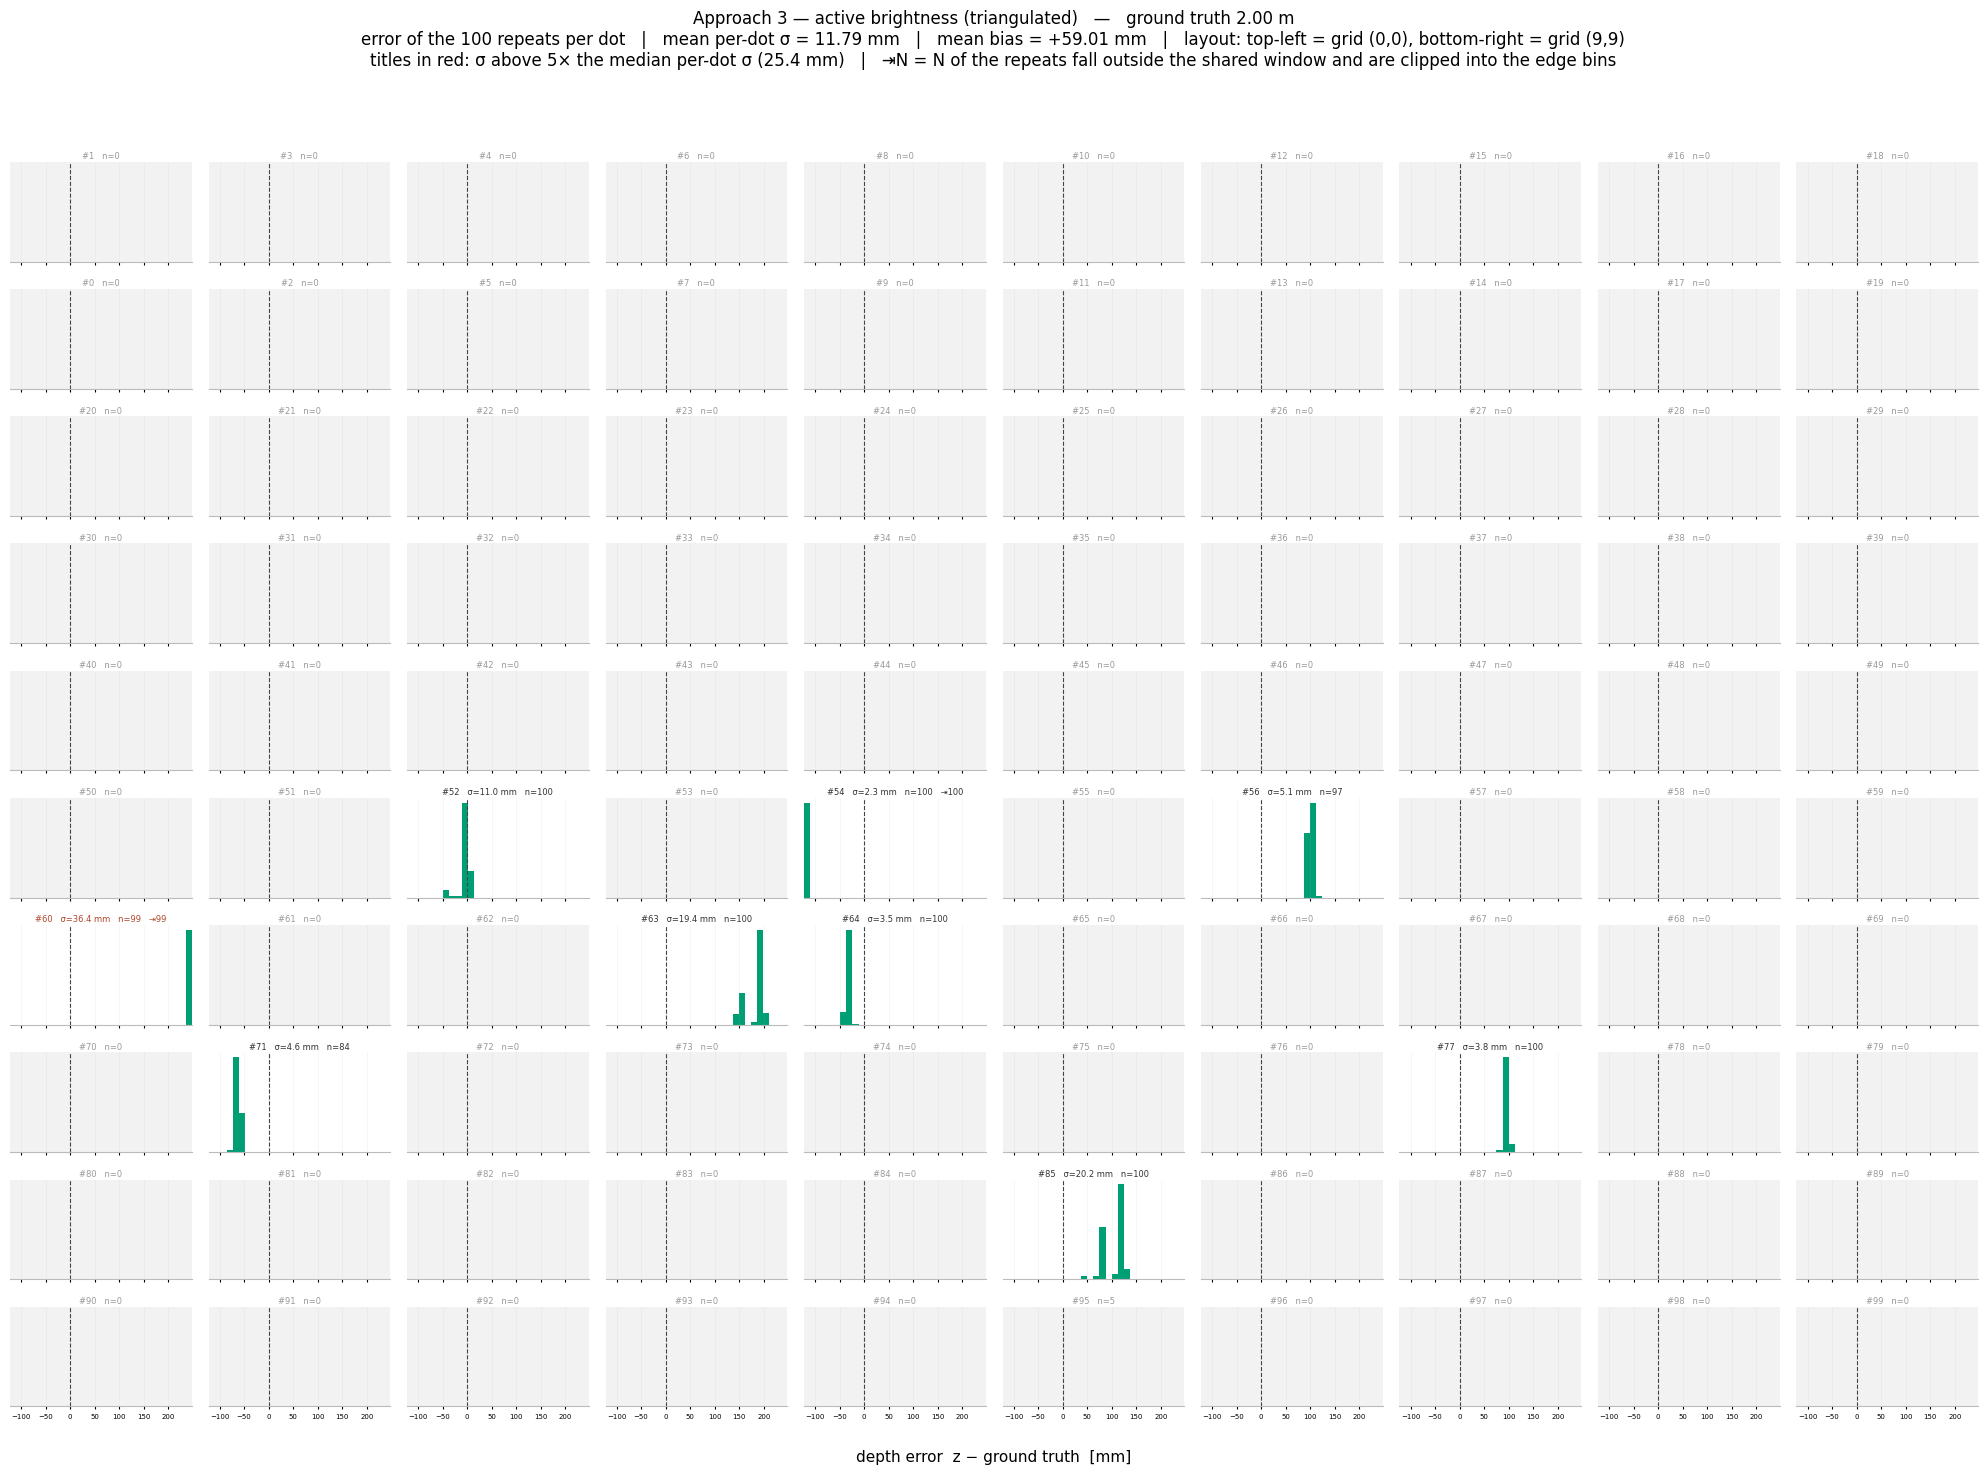

In [14]:
# ── Step E: 10×10 per-dot error distributions ────────────────────────────────
SHOW_DISTANCES  = [0.50, 1.00, 1.50, 2.00]   # ← pick freely; nearest measured is used
SHOW_APPROACHES = [1, 2, 3]                  # ← 1/2/3, or 4 = iToF-only, 5 = SL-only


def plot_dot_grid(series_idx, dist_idx, xlim=None, bins=30):
    """One panel per dot, laid out like the projected pattern: histogram of the
    100 repeats' error against ground truth. Shared x-axis across all cells."""
    gt = float(dists[dist_idx])
    err = (Zv[series_idx, dist_idx] - gt) * 1e3          # (repeats, dots) [mm]
    if not np.any(np.isfinite(err)):
        print(f"no valid samples for '{SERIES[series_idx]}' at {gt:.2f} m")
        return None

    # Window from the per-dot medians, not from all samples: a handful of dots
    # can be off by half a metre, and a 1–99 percentile over the raw samples
    # would squash every well-behaved dot into a single bin. Always keeps 0
    # (= ground truth) in frame; samples outside are clipped into the edge bins
    # and counted in the panel title.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        sd = sigma_dot[series_idx, dist_idx] * 1e3       # per-dot σ [mm]
        bd = bias_dot[series_idx, dist_idx] * 1e3        # per-dot bias [mm]
        s_med = float(np.nanmedian(sd))
        lo = min(0.0, float(np.nanpercentile(bd, 10)) - 3 * s_med)
        hi = max(0.0, float(np.nanpercentile(bd, 90)) + 3 * s_med)
    if xlim is None:
        if not np.isfinite(lo) or not np.isfinite(hi) or hi - lo < 1e-6:
            lo, hi = -1.0, 1.0
        pad = max(0.08 * (hi - lo), 0.05)
        xlim = (lo - pad, hi + pad)
    edges = np.linspace(xlim[0], xlim[1], bins + 1)
    color = SERIES_COLOR[series_idx]
    outlier_cut = 5 * s_med if np.isfinite(s_med) and s_med > 0 else np.inf

    fig, axes = plt.subplots(10, 10, figsize=(20, 15), sharex=True)
    for r in range(10):
        for c in range(10):
            dot = int(grid_ids[r, c])
            ax = axes[r, c]
            v = err[:, dot]
            v = v[np.isfinite(v)]
            if v.size >= MIN_VALID:
                off = int(np.sum((v < xlim[0]) | (v > xlim[1])))
                ax.hist(np.clip(v, xlim[0], xlim[1]), bins=edges,
                        color=color, edgecolor="none")
                sv = v.std()
                label = f"#{dot}   σ={sv:.1f} mm   n={v.size}"
                if off:
                    label += f"   ⇥{off}"
                ax.set_title(label, fontsize=6, pad=2,
                             color="#B3452C" if sv > outlier_cut else "#333333")
            else:
                ax.set_facecolor("#f2f2f2")
                ax.set_title(f"#{dot}   n={v.size}", fontsize=6, pad=2, color="#999999")
            ax.axvline(0, color="#444444", linewidth=0.8, linestyle="--")
            ax.set_xlim(*xlim)
            ax.set_yticks([])
            ax.tick_params(axis="x", labelsize=5, length=2)
            ax.grid(axis="x", alpha=0.15, linewidth=0.5)
            for sp in ("top", "right", "left"):
                ax.spines[sp].set_visible(False)
            ax.spines["bottom"].set_color("#bbbbbb")

    sm = np.nanmean(sigma_dot[series_idx, dist_idx]) * 1e3
    bm = np.nanmean(bias_dot[series_idx, dist_idx]) * 1e3
    fig.suptitle(f"{SERIES[series_idx]}   —   ground truth {gt:.2f} m\n"
                 f"error of the {N_REP} repeats per dot   |   "
                 f"mean per-dot σ = {sm:.2f} mm   |   mean bias = {bm:+.2f} mm   |   "
                 f"layout: top-left = grid (0,0), bottom-right = grid (9,9)\n"
                 f"titles in red: σ above 5× the median per-dot σ ({outlier_cut:.1f} mm)   |   "
                 "⇥N = N of the repeats fall outside the shared window and are "
                 "clipped into the edge bins",
                 fontsize=12)
    fig.supxlabel("depth error  z − ground truth  [mm]", fontsize=11)
    fig.tight_layout(rect=(0, 0.01, 1, 0.945))
    return fig


# Requests outside DISTANCE_RANGE would otherwise snap to its edge and redraw the
# same figure — skip them and say so instead.
_step = float(np.median(np.diff(dists))) if len(dists) > 1 else 0.05
_wanted, _skipped = [], []
for _d in SHOW_DISTANCES:
    _di = int(np.argmin(np.abs(dists - _d)))
    if abs(dists[_di] - _d) > 0.5 * _step:
        _skipped.append(_d)
    elif _di not in _wanted:
        _wanted.append(_di)
if _skipped:
    print(f"outside the selected range ({dists.min():.2f} … {dists.max():.2f} m), skipped: "
          + ", ".join(f"{d:.2f} m" for d in _skipped))

for _s in SHOW_APPROACHES:
    for _di in _wanted:
        plot_dot_grid(_s - 1, _di)
        plt.show()

## Result 2 — noise vs. distance

The headline comparison: x = distance, y = standard deviation, one curve per approach. σ is the
mean of the 100 per-dot σ values, i.e. pure temporal repeatability with the fixed per-dot bias
removed; the band shows the 10th–90th percentile across the dots. The bias and validity panels
below share the same x-axis.

**What the measurement shows about range.** Approaches 2 and 3 lose dots steadily beyond ~1.3 m
and reach 0 % valid at ~2.9 m: the ε-gate (`approaches.EPS_THRESHOLD = 0.1`) rejects every AB
peak once the iToF depth and the trail's triangulated depth no longer agree. Approach 1 keeps
~99 % of its dots at every distance, but that is not accuracy — its min-ε scan simply lands
somewhere on the trail, and past ~1.4 m the selected sample drifts, which is why its σ and its
bias both grow to the hundreds of millimetres. Running the unchanged single-frame pipeline on the
separate `Pictures/Test/FlatWallSchmersalReal` scenes reproduces the same drop-off (Approach 3:
89 % valid at 0.5 m, 52 % at 1.5 m, 9 % at 2.0 m, 0 % from 3.0 m), so this is a property of the
0.402 – 2.0 m calibration and the approaches themselves, not of the sweep. Read the far-range
columns as "out of range", not as a noise measurement.

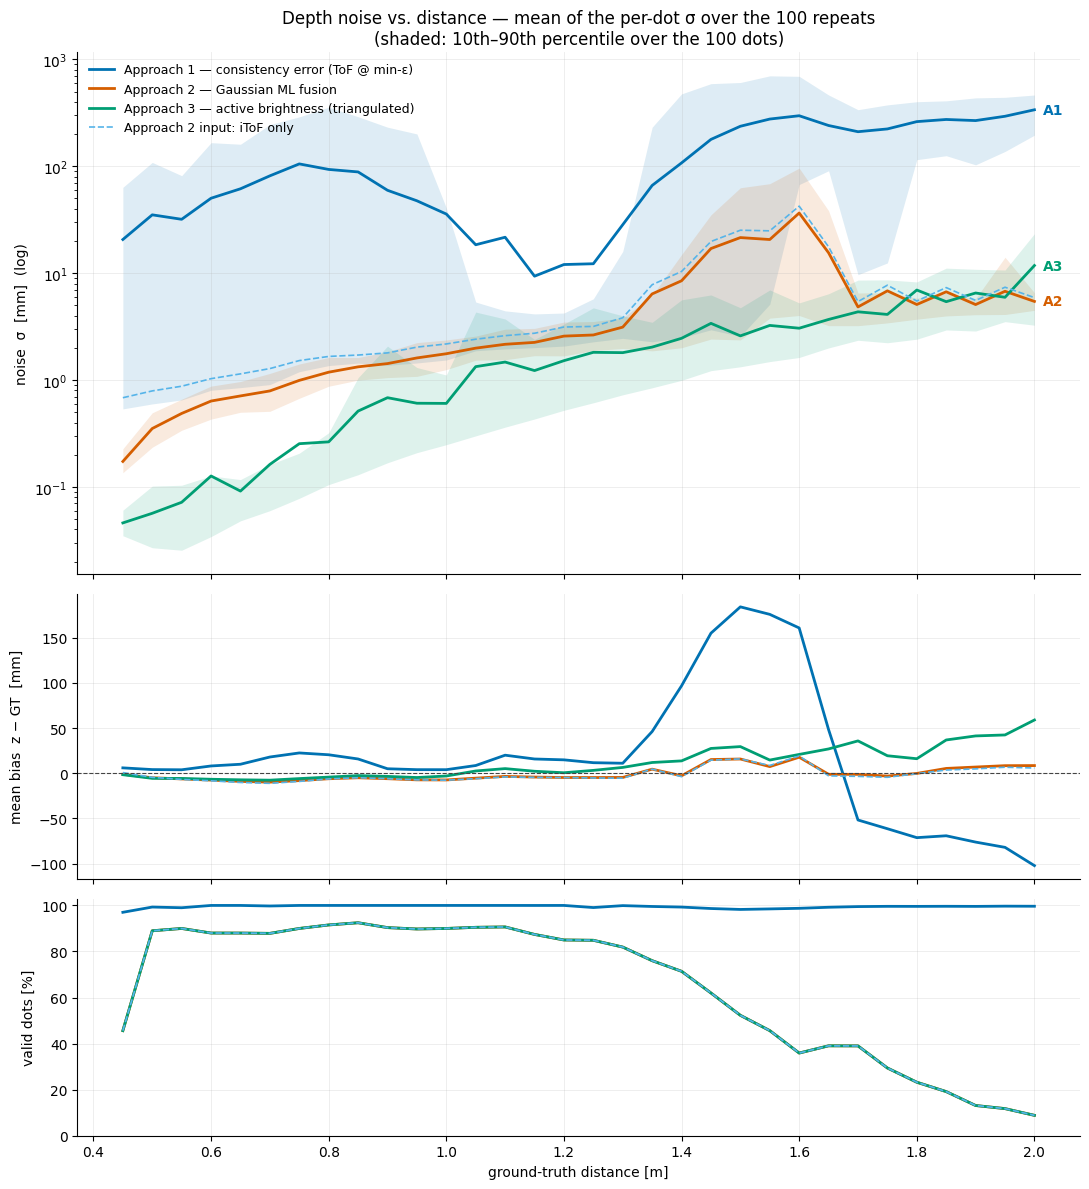

 dist [m]   σ A1 [mm]   σ A2 [mm]   σ A3 [mm]  bias A1 [mm]  bias A2 [mm]  bias A3 [mm]
     0.45       20.65        0.17        0.05         +6.01         -1.09         -1.56
     0.50       35.15        0.35        0.06         +4.10         -4.93         -5.60
     0.55       31.92        0.49        0.07         +3.89         -6.24         -5.71
     0.60       50.27        0.64        0.13         +8.12         -7.55         -6.62
     0.65       61.61        0.71        0.09        +10.01         -9.00         -7.22
     0.70       81.43        0.79        0.16        +18.03         -9.80         -7.63
     0.75      105.30        0.99        0.25        +22.53         -8.10         -5.87
     0.80       93.48        1.18        0.26        +20.51         -6.04         -4.21
     0.85       88.58        1.33        0.51        +15.84         -4.96         -2.57
     0.90       59.63        1.43        0.68         +5.02         -6.00         -3.44
     0.95       47.57        1.6

In [15]:
# ── Step F: overall noise per distance ───────────────────────────────────────
# One axis per measure — σ, bias and validity live in separate stacked panels
# sharing the distance axis (never a second y-scale on the same panel).
# Series 4 ("SL only") is by construction the same number Approach 3 returns —
# both are z_sl at the refined trail coordinate under the same ε-gate — so it is
# left out of the default plot. Add it back to confirm the two curves coincide.
SUMMARY_SERIES = [0, 1, 2, 3]

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True,
                         gridspec_kw={"height_ratios": [2.2, 1.2, 1.0]})
ax_s, ax_b, ax_v = axes

for s in SUMMARY_SERIES:
    c, ls, lw = SERIES_COLOR[s], SERIES_STYLE[s], SERIES_LW[s]
    ax_s.plot(dists, sigma_mean[s] * 1e3, ls, color=c, linewidth=lw, label=SERIES[s])
    if s < 3:   # spread band only for the three approaches — 5 bands is unreadable
        ax_s.fill_between(dists, sigma_p10[s] * 1e3, sigma_p90[s] * 1e3,
                          color=c, alpha=0.13, linewidth=0)
    ax_b.plot(dists, bias_mean[s] * 1e3, ls, color=c, linewidth=lw)
    ax_v.plot(dists, valid_frac[s] * 100, ls, color=c, linewidth=lw)

# Log scale: the approaches differ by three orders of magnitude in the range
# where they all still work — on a linear axis Approach 1 flattens the others.
ax_s.set_yscale("log")
ax_s.set_ylabel("noise  σ  [mm]  (log)")
ax_s.set_title("Depth noise vs. distance — mean of the per-dot σ over the "
               f"{N_REP} repeats\n(shaded: 10th–90th percentile over the {N_DOTS} dots)",
               fontsize=12)
ax_s.legend(fontsize=9, frameon=False, loc="upper left")

ax_b.axhline(0, color="#444444", linewidth=0.8, linestyle="--")
ax_b.set_ylabel("mean bias  z − GT  [mm]")

ax_v.set_ylabel("valid dots [%]")
ax_v.set_ylim(0, 103)
ax_v.set_xlabel("ground-truth distance [m]")

for ax in axes:
    ax.grid(alpha=0.25, linewidth=0.6)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

# Direct labels for the three approaches at the right edge — identity is never
# carried by colour alone.
for s in (0, 1, 2):
    if s in SUMMARY_SERIES:
        y = sigma_mean[s, -1] * 1e3
        if np.isfinite(y):
            ax_s.annotate(f"A{s + 1}", (dists[-1], y), xytext=(6, 0),
                          textcoords="offset points", color=SERIES_COLOR[s],
                          fontsize=10, fontweight="bold", va="center")

fig.tight_layout()
plt.show()

# Table view — the same numbers, readable without colour.
print(f"{'dist [m]':>9}" + "".join(f"{'σ A%d [mm]' % (s + 1):>12}" for s in range(3))
      + "".join(f"{'bias A%d [mm]' % (s + 1):>14}" for s in range(3)))
for di in range(N_DIST):
    print(f"{dists[di]:>9.2f}"
          + "".join(f"{sigma_mean[s, di] * 1e3:>12.2f}" for s in range(3))
          + "".join(f"{bias_mean[s, di] * 1e3:>+14.2f}" for s in range(3)))

## Result 3 — per-dot behaviour over distance

Which dots degrade first, and where. The heatmap gives all 100 dots × 67 distances at a glance;
the small multiples below show the same σ(distance) curve per dot, in the pattern layout.

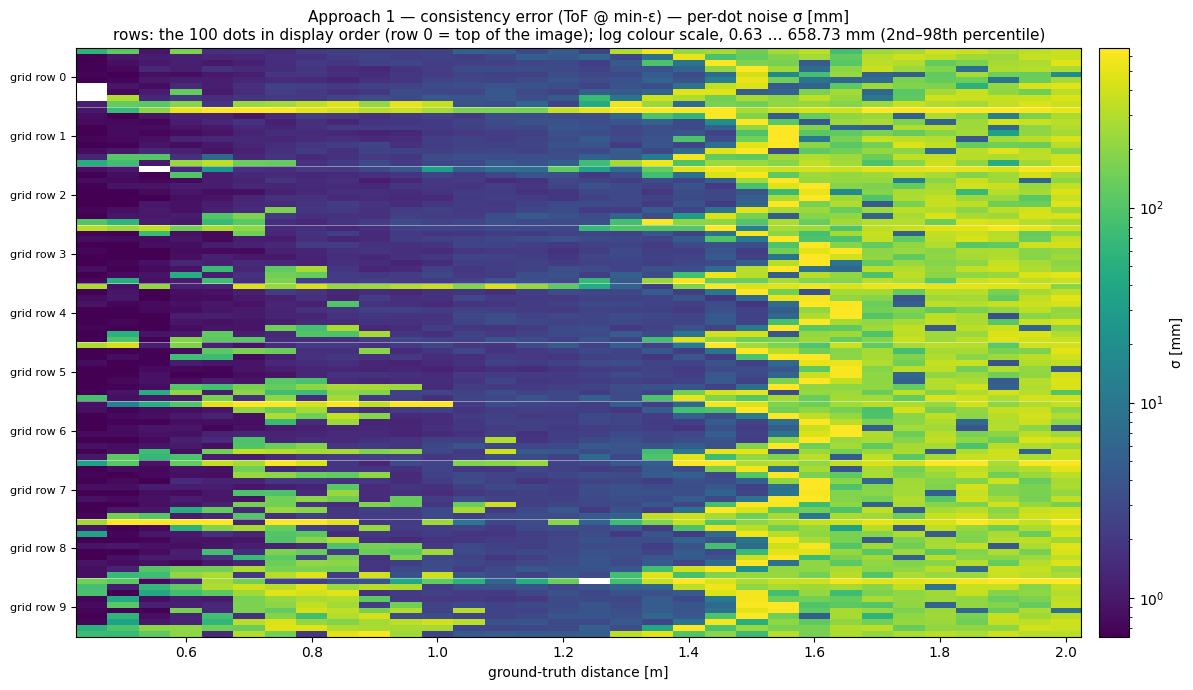

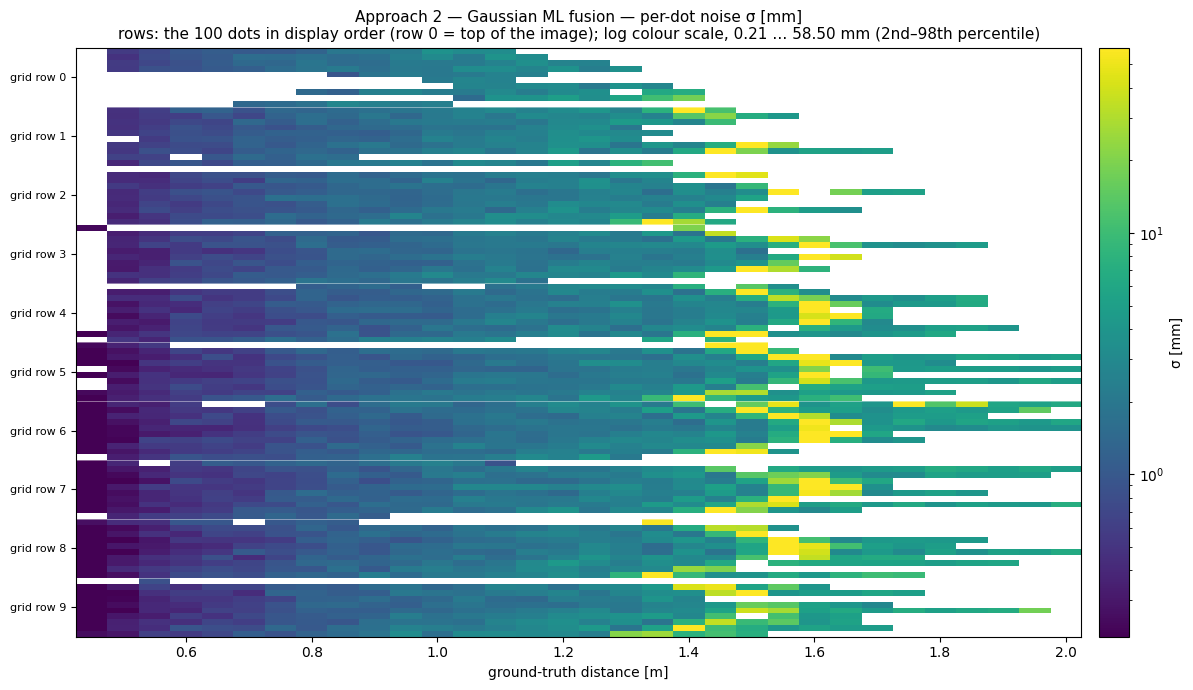

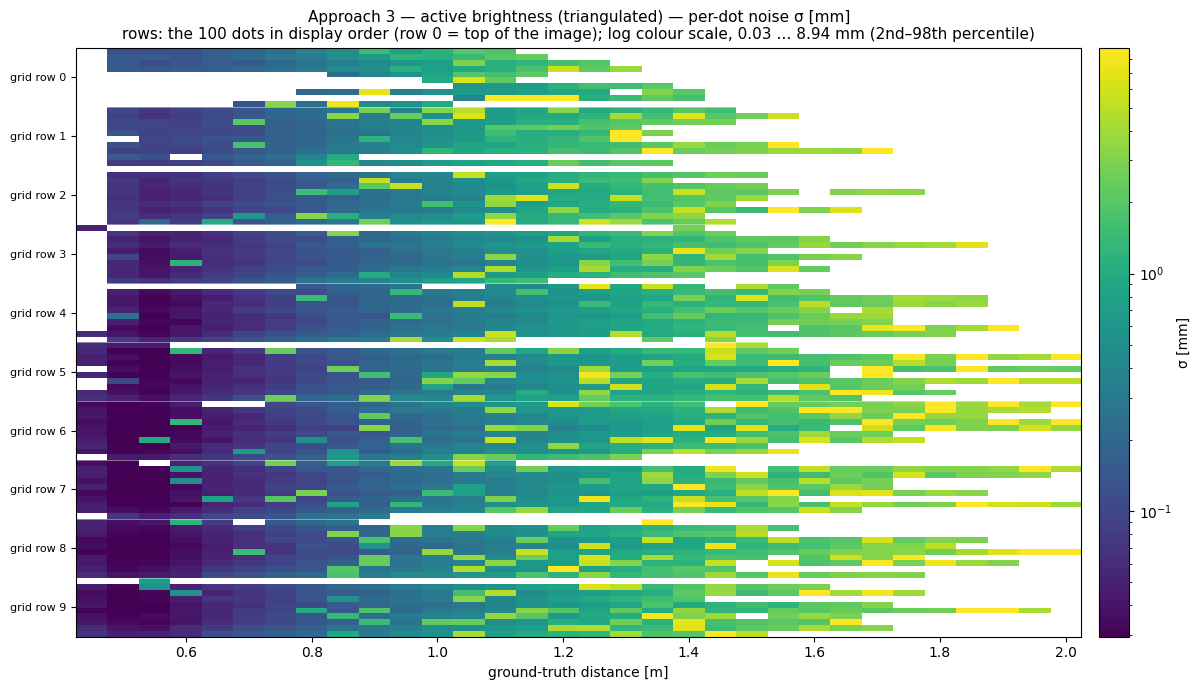

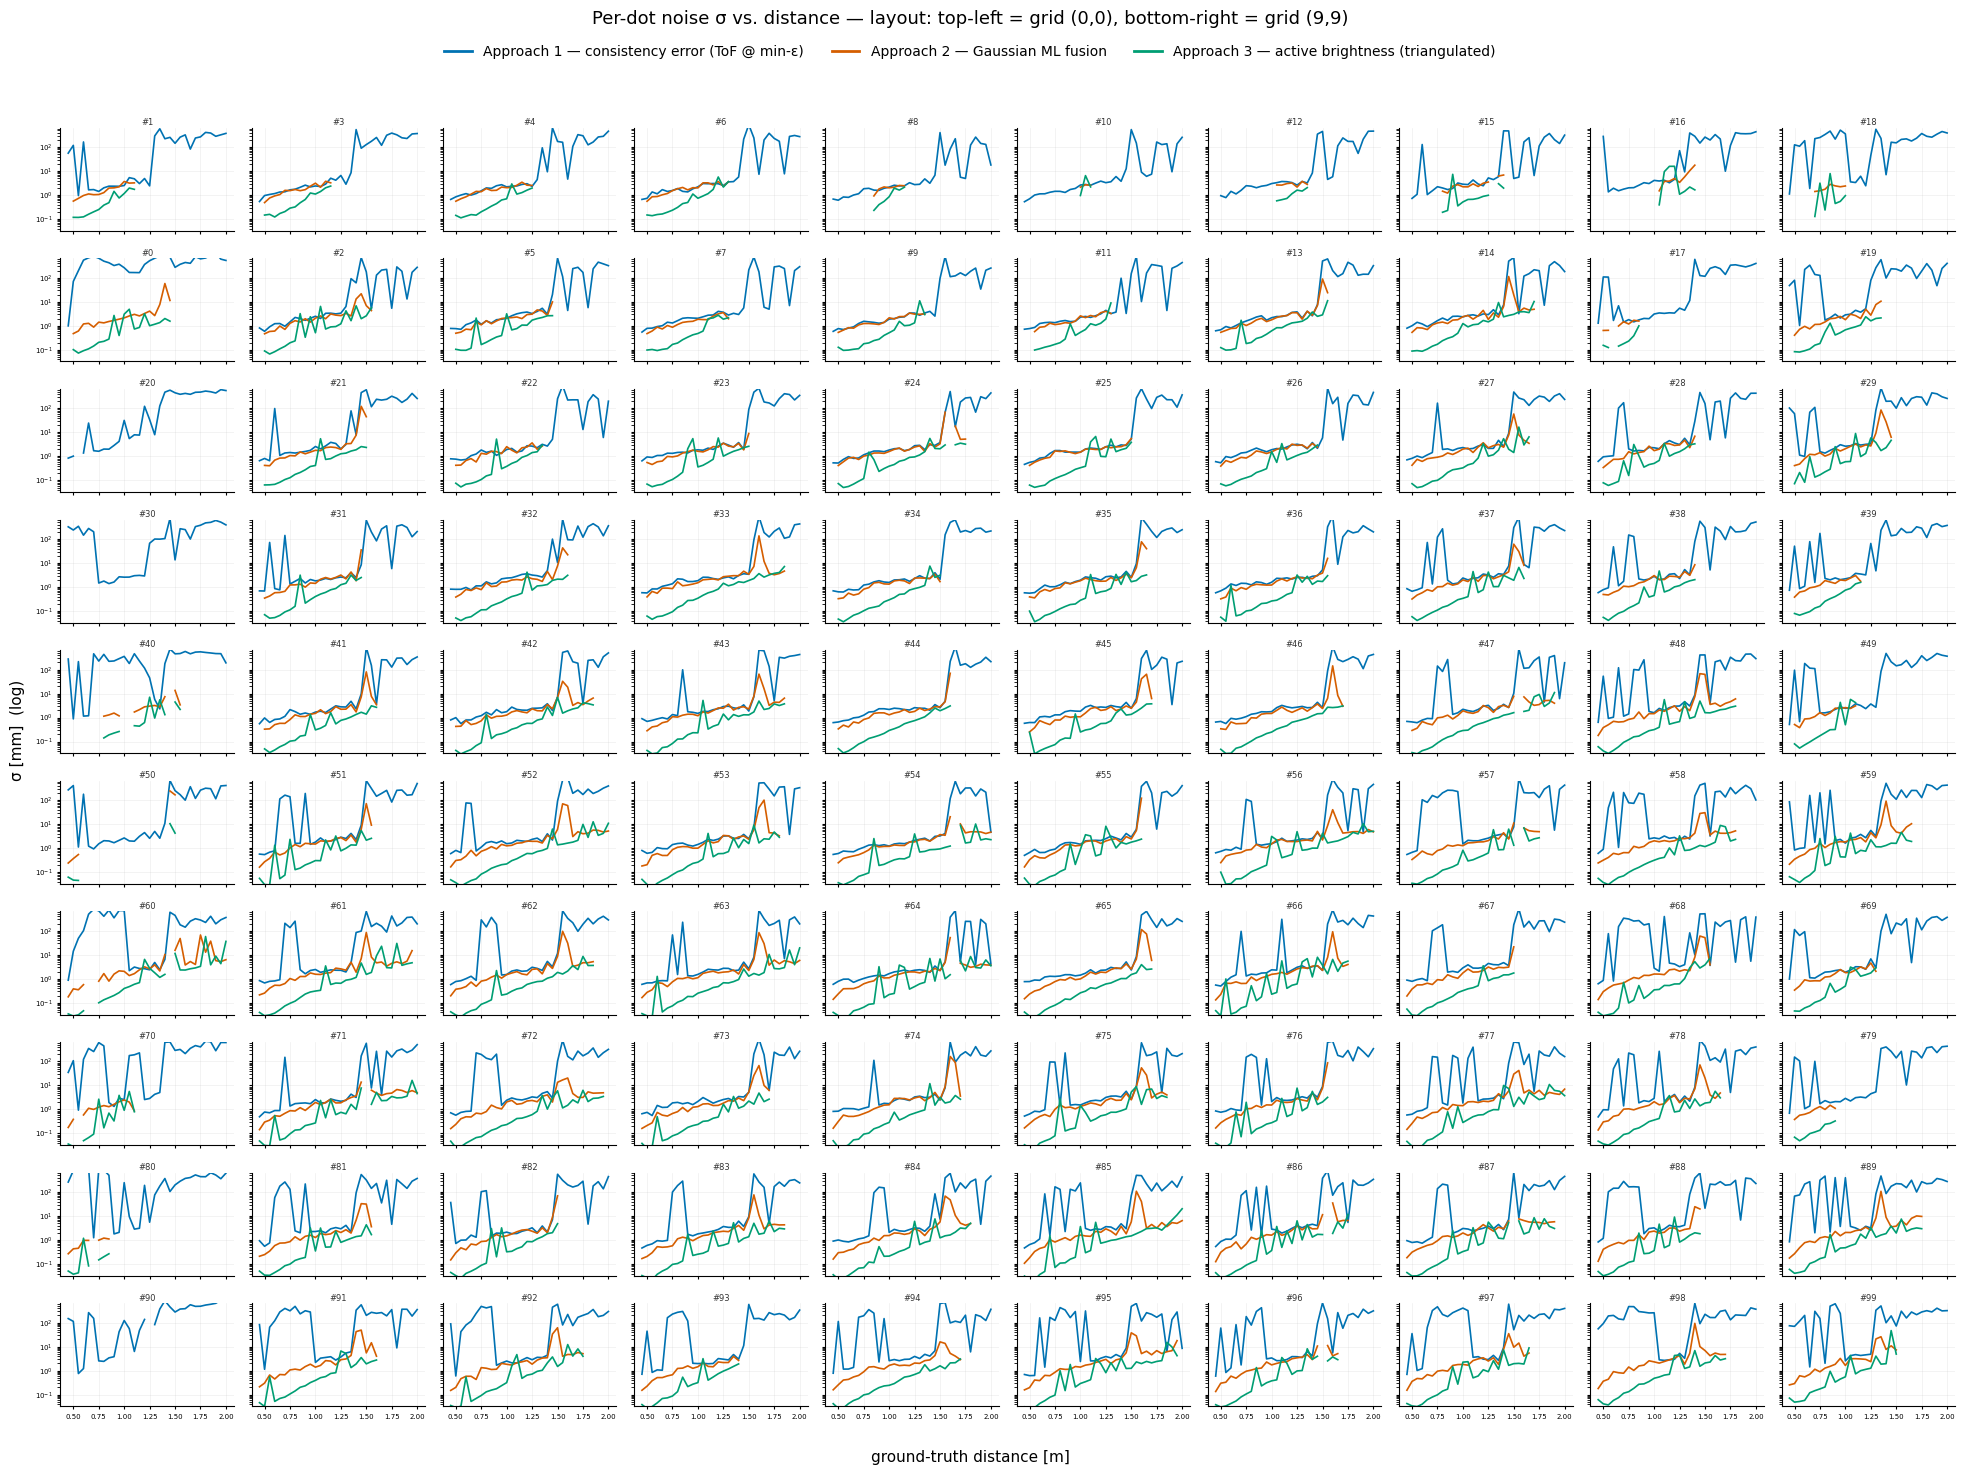

In [16]:
# ── Step G: how each individual dot behaves over distance ────────────────────
PERDOT_APPROACHES = [1, 2, 3]

import matplotlib

# (a) heatmap — rows are the 100 dots in display order, columns the distances.
#     Sequential magnitude → one perceptually uniform ramp, light → dark.
_flat = grid_ids.ravel()
for _s in PERDOT_APPROACHES:
    s = _s - 1
    M = sigma_dot[s][:, _flat].T * 1e3                      # (dots, distances) [mm]
    finite = M[np.isfinite(M)]
    vmax = float(np.percentile(finite, 98)) if finite.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    half = (dists[-1] - dists[0]) / (2 * max(len(dists) - 1, 1)) if len(dists) > 1 else 0.025

    vmin = max(float(np.percentile(finite, 2)), 1e-3) if finite.size else 1e-3
    fig, ax = plt.subplots(figsize=(13, 7))
    im = ax.imshow(M, aspect="auto", origin="upper", cmap="viridis",
                   norm=matplotlib.colors.LogNorm(vmin=vmin, vmax=max(vmax, vmin * 10)),
                   extent=(dists[0] - half, dists[-1] + half, 100, 0),
                   interpolation="nearest")
    for r in range(1, 10):
        ax.axhline(r * 10, color="white", linewidth=0.6, alpha=0.5)
    ax.set_yticks(np.arange(5, 100, 10))
    ax.set_yticklabels([f"grid row {r}" for r in range(10)], fontsize=8)
    ax.set_xlabel("ground-truth distance [m]")
    ax.set_title(f"{SERIES[s]} — per-dot noise σ [mm]\n"
                 "rows: the 100 dots in display order (row 0 = top of the image); "
                 f"log colour scale, {vmin:.2f} … {vmax:.2f} mm "
                 "(2nd–98th percentile)", fontsize=11)
    cb = fig.colorbar(im, ax=ax, pad=0.015)
    cb.set_label("σ [mm]")
    fig.tight_layout()
    plt.show()

# (b) the same data as 100 small multiples, laid out like the dot pattern.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    _ymax = float(np.nanpercentile(sigma_dot[[s - 1 for s in PERDOT_APPROACHES]] * 1e3, 99))
    _ymin = float(np.nanpercentile(sigma_dot[[s - 1 for s in PERDOT_APPROACHES]] * 1e3, 1))
if not np.isfinite(_ymax) or _ymax <= 0:
    _ymax = 1.0
if not np.isfinite(_ymin) or _ymin <= 0:
    _ymin = max(_ymax * 1e-4, 1e-3)
fig, axes = plt.subplots(10, 10, figsize=(20, 15), sharex=True, sharey=True)
for r in range(10):
    for c in range(10):
        dot = int(grid_ids[r, c])
        ax = axes[r, c]
        for _s in PERDOT_APPROACHES:
            s = _s - 1
            ax.plot(dists, sigma_dot[s, :, dot] * 1e3, SERIES_STYLE[s],
                    color=SERIES_COLOR[s], linewidth=1.2)
        ax.set_title(f"#{dot}", fontsize=6, pad=2, color="#333333")
        ax.set_yscale("log")           # A1 and A3 differ by ~3 decades
        ax.set_ylim(_ymin, _ymax)
        ax.tick_params(labelsize=5, length=2)
        ax.grid(alpha=0.2, linewidth=0.5)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)

_handles = [plt.Line2D([], [], color=SERIES_COLOR[s - 1], linestyle=SERIES_STYLE[s - 1],
                       linewidth=2, label=SERIES[s - 1]) for s in PERDOT_APPROACHES]
fig.legend(handles=_handles, loc="upper center", ncol=len(_handles),
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.965))
fig.suptitle("Per-dot noise σ vs. distance — layout: top-left = grid (0,0), "
             "bottom-right = grid (9,9)", fontsize=13)
fig.supxlabel("ground-truth distance [m]", fontsize=11)
fig.supylabel("σ [mm]  (log)", fontsize=11)
fig.tight_layout(rect=(0.01, 0.01, 1, 0.94))
plt.show()